# Executive Summary

In this project, I develop a model to predict house prices using the Ames housing dataset. The dataset includes 80 types of information about each property, such as neighborhood, utilities, and lot size. Using the training data, I build a model to estimate sale prices and evaluate its accuracy with the test data. To prepare the data, I clean and organize the dataset by identifying data types, filling in missing values, and removing unsuitable records. After processing and converting categorical information, the total number of features expands from 80 to 654. Through model selection and tuning, I determine that the best-performing model used 105 key factors, balancing accuracy and generalization. The final model achieves a testing score (Root Mean Squared Error) of 20,791 on the test data, demonstrating strong predictive performance.

# Preparation

In [3]:
!pwd
!ls

/content
drive  sample_data


In [ ]:
%cd drive/MyDrive/School/University-of-Guelph/MDS/Course/F25_DATA-6100-01_Introduction-to-Data-Science/Project1

In [5]:
# ### Import necessary Python packages and set environment options ### #
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydantic import BaseModel, computed_field
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_rows", 100)

# Data Pre-Processing

Carry out the data pre-processing in the following steps:

<br>&nbsp; **Step 1.** &nbsp; Identify whether each column is categorical or numerical.
<br>&nbsp; **Step 2.** &nbsp; Verify that the data type of each column is appropriate.
<br>&nbsp; **Step 3.** &nbsp; Handle missing records.
<br>&nbsp; **Step 4.** &nbsp; Check whether all categorical columns follow the definitions in *data_description.txt*.
<br>&nbsp; **Step 5.** &nbsp; Detect outliers for numerical columns.
<br>&nbsp; **Step 6.** &nbsp; Modify data.

<br>

Steps 1 through 3 are performed on the combined DataFrame of the train and test datasets, as these evaluations are required for both. For convenience during preprocessing, I temporarily add a “SalePrice” column filled with zeros to the test data before concatenation.


In [6]:
# ### Import Train and Test Data ### #
train_df = pd.read_csv("1_data/Housing_Data_Train.csv", index_col=0)
test_df = pd.read_csv("1_data/Housing_Data_Test.csv", index_col=0)
print(f"### train_df ###\n{train_df}\n\n")
print(f"### test_df ###\n{test_df}\n")

### train_df ###
       Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0     149          20       RL         63.0     7500   Pave   NaN      Reg   
1     460          50       RL          NaN     7015   Pave   NaN      IR1   
2    1336          20       RL         80.0     9650   Pave   NaN      Reg   
3     805          20       RL         75.0     9000   Pave   NaN      Reg   
4    1396          60       RL         88.0    12665   Pave   NaN      IR1   
..    ...         ...      ...          ...      ...    ...   ...      ...   
995   912          20       RL          NaN     9286   Pave   NaN      IR1   
996   916         160       RM         21.0     2001   Pave   NaN      Reg   
997   399          30       RM         60.0     8967   Pave   NaN      Reg   
998   381          50       RL         50.0     5000   Pave  Pave      Reg   
999   151          20       RL        120.0    10356   Pave   NaN      Reg   

    LandContour Utilities  ... PoolArea PoolQC

In [7]:
# ### Concatenate Train and Test Data ### #
# Zero filling
test_df["SalePrice"] = 0

mix_df = pd.concat([train_df, test_df], ignore_index=True)
print(f"### mix_df ###\n{mix_df}\n")

### mix_df ###
        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0      149          20       RL         63.0     7500   Pave   NaN      Reg   
1      460          50       RL          NaN     7015   Pave   NaN      IR1   
2     1336          20       RL         80.0     9650   Pave   NaN      Reg   
3      805          20       RL         75.0     9000   Pave   NaN      Reg   
4     1396          60       RL         88.0    12665   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1441  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1442  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1443  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1444  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1445  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... Pool

### Step 1
After reviewing *data_description.txt*, I classified each column (except for “Id”) as categorical or numerical. In total, I identified 60 categorical columns and 20 numerical columns, with “SalePrice” included among the numerical features.

In [8]:
# ### Define Categorical and Numerical Columns ### #
original_columns = mix_df.columns
id_column = ["Id"]
categorical_columns = [
    "MSSubClass", "MSZoning", "Street", "Alley", "LotShape",
    "LandContour", "Utilities", "LotConfig", "LandSlope", "Neighborhood",
    "Condition1", "Condition2", "BldgType", "HouseStyle", "OverallQual",
    "OverallCond", "YearBuilt", "YearRemodAdd", "RoofStyle", "RoofMatl",
    "Exterior1st", "Exterior2nd", "MasVnrType", "ExterQual", "ExterCond",
    "Foundation", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "Heating", "HeatingQC", "CentralAir", "Electrical",
    "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath", "BedroomAbvGr",
    "KitchenAbvGr", "KitchenQual", "TotRmsAbvGrd", "Functional", "Fireplaces",
    "FireplaceQu", "GarageType", "GarageYrBlt", "GarageFinish", "GarageCars",
    "GarageQual", "GarageCond", "PavedDrive", "PoolQC", "Fence",
    "MiscFeature", "MoSold", "YrSold", "SaleType", "SaleCondition"
]
numerical_columns = [
    "LotFrontage",
    "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea",
    "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch",
    "ScreenPorch", "PoolArea", "MiscVal", "SalePrice"
]

## Step 2
Inspect the default data types of all columns.
<br><br>
The “**GarageYrBlt**” column is loaded as float64, but it should be **int64** since it is treated as categorical.

In [9]:
# ### Check Data Types of Columns ### #
print(f"### dtypes ###\n{mix_df.dtypes}\n")

### dtypes ###
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating   

## Step 3

Display null records in the data.
<br><br>
As a result of reviewing, a substantial number of missing records are detected. For categorical columns, missing values appear to represent “NA” or “None.” These are filled accordingly, following the definitions in *data_description.txt*. Most numerical columns with missing values are filled with zeros, except for “**LotFrontage**”, which has **259 missing records** across the train and test datasets. This column required further investigation.

In [10]:
# ### Display Number of Missing Values per Column ### #
print(f"### null ###\n{mix_df.isnull().sum(axis=0)}")

### null ###
Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1356
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        866
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           36
BsmtCond           36
BsmtExposure       37
BsmtFinType1       36
BsmtFinSF1          0
BsmtFinType2       37
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF           

Upon review, "LotFrontage" shows a positive correlation with "LotArea", with a correlation coefficient of approximately **0.705** after removing outliers. Based on this relationship, missing values of "LotFrontage" are estimated using the formula:

 $LotFrontage$ $=$ $0.01$ $×$ $LotArea$

However, since this imputation approach is an approximation, I will retain both the imputed and non-imputed versions for comparison during model tuning.

Correlation between non-null LotFrontage & LotArea: 0.43179304324086026
Correlation between non-null LotFrontage & LotArea (without outliers): 0.704911107595007
Linear fit polynomial:  
111.2 x + 1520


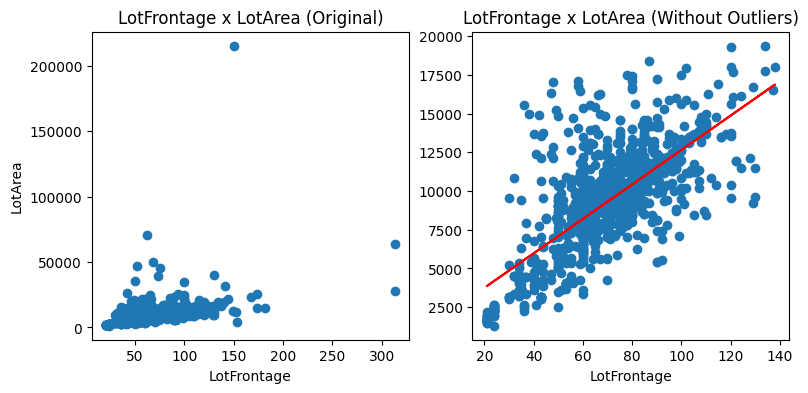

In [11]:
# ### See the relation between "LotFrontage" & "LotArea" ### #
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# The original scatter plot
lot_corr_x: pd.Series = mix_df[(mix_df["LotFrontage"].notnull())]["LotFrontage"]
lot_corr_y: pd.Series = mix_df[(mix_df["LotFrontage"].notnull())]["LotArea"]

lot_corr: float = lot_corr_y.corr(lot_corr_x)
print(f"Correlation between non-null LotFrontage & LotArea: {lot_corr}")

# plt.subplot(2, 1, 1)
axs[0].set_title("LotFrontage x LotArea (Original)")
axs[0].set_xlabel("LotFrontage")
axs[0].set_ylabel("LotArea")
axs[0].scatter(lot_corr_x, lot_corr_y)

# Modified scatter plot
lot_mod_corr_x: pd.Series = mix_df[
    (mix_df["LotFrontage"].notnull()) &
    (mix_df["LotFrontage"] < 140) &
    (mix_df["LotArea"] < 20000)
]["LotFrontage"]
lot_mod_corr_y: pd.Series = mix_df[
    (mix_df["LotFrontage"].notnull()) &
    (mix_df["LotFrontage"] < 140) &
    (mix_df["LotArea"] < 20000)
]["LotArea"]
lot_mod_corr: float = lot_mod_corr_y.corr(lot_mod_corr_x)
lot_mod_linfit_poly = np.poly1d(
    np.polyfit(
        lot_mod_corr_x, lot_mod_corr_y, 1
    )
)
print(f"Correlation between non-null LotFrontage & LotArea (without outliers): {lot_mod_corr}")
print(f"Linear fit polynomial: {lot_mod_linfit_poly}")

# plt.subplot(2, 1, 2)
axs[1].set_title("LotFrontage x LotArea (Without Outliers)")
axs[1].set_xlabel("LotFrontage")
axs[1].scatter(lot_mod_corr_x, lot_mod_corr_y)
axs[1].plot(lot_mod_corr_x, lot_mod_linfit_poly(lot_mod_corr_x), color='red')

## Step 4
Check whether all categorical columns follow the definitions in *data_description.txt*, using helper functions to streamline the validation process.
<br><br>
As a result of evaluation, I see that most categorical columns are valid, though I find minor inconsistencies and typos in *data_description.txt*. The “**Exterior2nd**” column contains several mistyped entries, which I correct by mapping them to the appropriate categories. The “**BldgType**” column includs the value “**Twnhs**”, which is not listed in *data_description.txt*. I decide to retain these records since there are over 40 of them and no clear alternative category could be assigned.

In [12]:
# ### Prepare Functions for Efficient Evaluation of Categorical Columns ### #

# ### Variables Setup ### #
column: str = "MSSubClass"
categories_list: list = []
categories_str: str = """
        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES
"""
# For numerical categories
# categories_list = range(int(train_df[column].min()), int(train_df[column].max()) + 1)


# ### Functions ### #
def extract_categories(
    train_df: pd.DataFrame, column: str, categories_str: str
) -> list[str | int]:
    categories_list: list = []
    for line in categories_str.splitlines():
        if len(line) > 0:
            element = line.strip().split(sep="\t")[0]
            if pd.api.types.is_numeric_dtype(train_df[column]):
                categories_list.append(int(element))
            else:
                categories_list.append(element)
    return categories_list

def eval_categorical_column(
    train_df: pd.DataFrame, column: str, categories_list: list
) -> tuple[pd.DataFrame, str]:
    eval_df = train_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]

    eval_lines: str = f"column = \"{column}\"\n"
    eval_lines += f"categories_list = {categories_list}\n"
    eval_lines += f"eval_df = train_df.dropna(subset=[column])[column]\n"
    eval_lines += f"eval_df = eval_df[~eval_df.isin(categories_list)]\n"
    eval_lines += f"print(column, \"\\n\", eval_df, \"\\n\")"

    return eval_df, eval_lines


# ### Main ### #
if len(categories_list) == 0:
    categories_list = extract_categories(
        train_df=train_df,
        column=column,
        categories_str=categories_str
    )
eval_df, eval_lines = eval_categorical_column(
    train_df=train_df,
    column=column,
    categories_list=categories_list
)
print(f"### {column} ###\n\n{eval_df}\n\n{eval_lines}")

### MSSubClass ###

Series([], Name: MSSubClass, dtype: int64)

column = "MSSubClass"
categories_list = [20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 150, 160, 180, 190]
eval_df = train_df.dropna(subset=[column])[column]
eval_df = eval_df[~eval_df.isin(categories_list)]
print(column, "\n", eval_df, "\n")


In [13]:
# ### Validate Categorical Columns — Check Consistency with data_description.txt ### #
def evaluate_data(target_df: pd.DataFrame) -> None:
    column: str = ""
    eval_df = pd.DataFrame()

    # OK
    column = "MSSubClass"
    categories_list = [20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 150, 160, 180, 190]
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK (In data_desription: Add "C (all)")
    column = "MSZoning"
    categories_list = ['A', 'C', 'FV', 'I', 'RH', 'RL', 'RP', 'RM', 'C (all)']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Street"
    categories_list = ['Grvl', 'Pave']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK (In data_desription: "NA " -> "NA")
    column = "Alley"
    categories_list = ['Grvl', 'Pave', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "LotShape"
    categories_list = ['Reg', 'IR1', 'IR2', 'IR3']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "LandContour"
    categories_list = ['Lvl', 'Bnk', 'HLS', 'Low']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Utilities"
    categories_list = ['AllPub', 'NoSewr', 'NoSeWa', 'ELO']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "LotConfig"
    categories_list = ['Inside', 'Corner', 'CulDSac', 'FR2', 'FR3']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "LandSlope"
    categories_list = ['Gtl', 'Mod', 'Sev']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK (In data_desription: "Names" -> "NAmes")
    column = "Neighborhood"
    categories_list = ['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr', 'Crawfor', 'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel', 'NAmes', 'NoRidge', 'NPkVill', 'NridgHt', 'NWAmes', 'OldTown', 'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber', 'Veenker']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Condition1"
    categories_list = ['Artery', 'Feedr', 'Norm', 'RRNn', 'RRAn', 'PosN', 'PosA', 'RRNe', 'RRAe']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Condition2"
    categories_list = ['Artery', 'Feedr', 'Norm', 'RRNn', 'RRAn', 'PosN', 'PosA', 'RRNe', 'RRAe']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # "Twnhs" (In data_desription: "2FmCon" -> "2fmCon", "Duplx" -> "Duplex")
    column = "BldgType"
    categories_list = ['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'TwnhsI']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "HouseStyle"
    categories_list = ['1Story', '1.5Fin', '1.5Unf', '2Story', '2.5Fin', '2.5Unf', 'SFoyer', 'SLvl']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "OverallQual"
    categories_list = [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "OverallCond"
    categories_list = [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "YearBuilt"
    categories_list = range(1872, 2010)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "YearRemodAdd"
    categories_list = range(1950, 2011)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "RoofStyle"
    categories_list = ['Flat', 'Gable', 'Gambrel', 'Hip', 'Mansard', 'Shed']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "RoofMatl"
    categories_list = ['ClyTile', 'CompShg', 'Membran', 'Metal', 'Roll', 'Tar&Grv', 'WdShake', 'WdShngl']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Exterior1st"
    categories_list = ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'PreCast', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # "Brk Cmn" -> "BrkComm", "CmentBd" -> "CemntBd", "Wd Shng" -> "Wd Sdng"
    column = "Exterior2nd"
    categories_list = ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'PreCast', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "MasVnrType"
    categories_list = ['BrkCmn', 'BrkFace', 'CBlock', 'None', 'Stone']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "ExterQual"
    categories_list = ['Ex', 'Gd', 'TA', 'Fa', 'Po']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "ExterCond"
    categories_list = ['Ex', 'Gd', 'TA', 'Fa', 'Po']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Foundation"
    categories_list = ['BrkTil', 'CBlock', 'PConc', 'Slab', 'Stone', 'Wood']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "BsmtQual"
    categories_list = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "BsmtCond"
    categories_list = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "BsmtExposure"
    categories_list = ['Gd', 'Av', 'Mn', 'No', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "BsmtFinType1"
    categories_list = ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "BsmtFinType2"
    categories_list = ['GLQ', 'ALQ', 'BLQ', 'Rec', 'LwQ', 'Unf', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Heating"
    categories_list = ['Floor', 'GasA', 'GasW', 'Grav', 'OthW', 'Wall']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "HeatingQC"
    categories_list = ['Ex', 'Gd', 'TA', 'Fa', 'Po']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "CentralAir"
    categories_list = ['N', 'Y']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Electrical"
    categories_list = ['SBrkr', 'FuseA', 'FuseF', 'FuseP', 'Mix']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "BsmtFullBath"
    categories_list = range(0, 3)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "BsmtHalfBath"
    categories_list = range(0, 3)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "FullBath"
    categories_list = range(0, 4)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "HalfBath"
    categories_list = range(0, 3)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK (In data_desription: "Bedroom" -> "BedroomAbvGr")
    column = "BedroomAbvGr"
    categories_list = range(0, 9)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK (In data_desription: "Kitchen" -> "KitchenAbvGr")
    column = "KitchenAbvGr"
    categories_list = range(0, 4)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "KitchenQual"
    categories_list = ['Ex', 'Gd', 'TA', 'Fa', 'Po']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "TotRmsAbvGrd"
    categories_list = range(3, 15)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Functional"
    categories_list = ['Typ', 'Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'Sal']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Fireplaces"
    categories_list = range(0, 4)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "FireplaceQu"
    categories_list = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "GarageType"
    categories_list = ['2Types', 'Attchd', 'Basment', 'BuiltIn', 'CarPort', 'Detchd', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # float -> int
    column = "GarageYrBlt"
    categories_list = range(1900, 2011)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "GarageFinish"
    categories_list = ['Fin', 'RFn', 'Unf', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "GarageCars"
    categories_list = range(0, 5)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "GarageQual"
    categories_list = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "GarageCond"
    categories_list = ['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "PavedDrive"
    categories_list = ['Y', 'P', 'N']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "PoolQC"
    categories_list = ['Ex', 'Gd', 'TA', 'Fa', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "Fence"
    categories_list = ['GdPrv', 'MnPrv', 'GdWo', 'MnWw', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "MiscFeature"
    categories_list = ['Elev', 'Gar2', 'Othr', 'Shed', 'TenC', 'NA']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "MoSold"
    categories_list = range(1, 13)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "YrSold"
    categories_list = range(2006, 2011)
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK (In data_desription: "WD " -> "WD")
    column = "SaleType"
    categories_list = ['WD', 'CWD', 'VWD', 'New', 'COD', 'Con', 'ConLw', 'ConLI', 'ConLD', 'Oth']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    # OK
    column = "SaleCondition"
    categories_list = ['Normal', 'Abnorml', 'AdjLand', 'Alloca', 'Family', 'Partial']
    eval_df = target_df.dropna(subset=[column])[column]
    eval_df = eval_df[~eval_df.isin(categories_list)]
    print(column, "\n", eval_df, "\n")

    return None

evaluate_data(target_df=mix_df)


MSSubClass 
 Series([], Name: MSSubClass, dtype: int64) 

MSZoning 
 Series([], Name: MSZoning, dtype: object) 

Street 
 Series([], Name: Street, dtype: object) 

Alley 
 Series([], Name: Alley, dtype: object) 

LotShape 
 Series([], Name: LotShape, dtype: object) 

LandContour 
 Series([], Name: LandContour, dtype: object) 

Utilities 
 Series([], Name: Utilities, dtype: object) 

LotConfig 
 Series([], Name: LotConfig, dtype: object) 

LandSlope 
 Series([], Name: LandSlope, dtype: object) 

Neighborhood 
 Series([], Name: Neighborhood, dtype: object) 

Condition1 
 Series([], Name: Condition1, dtype: object) 

Condition2 
 Series([], Name: Condition2, dtype: object) 

BldgType 
 10      Twnhs
29      Twnhs
54      Twnhs
126     Twnhs
130     Twnhs
200     Twnhs
222     Twnhs
226     Twnhs
233     Twnhs
310     Twnhs
345     Twnhs
349     Twnhs
373     Twnhs
398     Twnhs
594     Twnhs
634     Twnhs
635     Twnhs
662     Twnhs
679     Twnhs
690     Twnhs
715     Twnhs
717     Twnhs


## Step 5

Examine the distributions of all numerical columns and identify several potential outliers.
<br><br>
By plotting the distributions of the numerical features, we can observe that most columns contain a few data points that deviate significantly from the main cluster. Although determining outliers involves some subjectivity, the following thresholds are applied to remove clearly abnormal values:

* **"LotFrontage" <= 200**,
* **"LotArea" <= 100000**,
* **"BsmtFinSF1" <= 3000**,
* **"BsmtFinSF2" <= 1200**,
* **"TotalBsmtSF" <= 4000**,
* **"1stFlrSF" <= 3200**,
* **"GrLivArea" <= 4000**,
* **"OpenPorchSF" <= 350**,
* **"EnclosedPorch" <= 350**,
* **"3SsnPorch" <= 400**,
* **"MiscVal" <= 4000**.

*The columns "MasVnrArea", "BsmtUnfSF", "2ndFlrSF", "GarageArea", "WoodDeckSF", and "ScreenPorch" appear acceptable without filtering. Data points in  "LowQualFinSF" and "PoolArea" that deviate from zero were retained, as they may capture meaningful information within those features.
<br><br>

Since handling outliers requires careful judgment and the effects of these conditions are uncertain, both the original and outlier-removed versions of the dataset will be evaluated in the Model Tuning section.


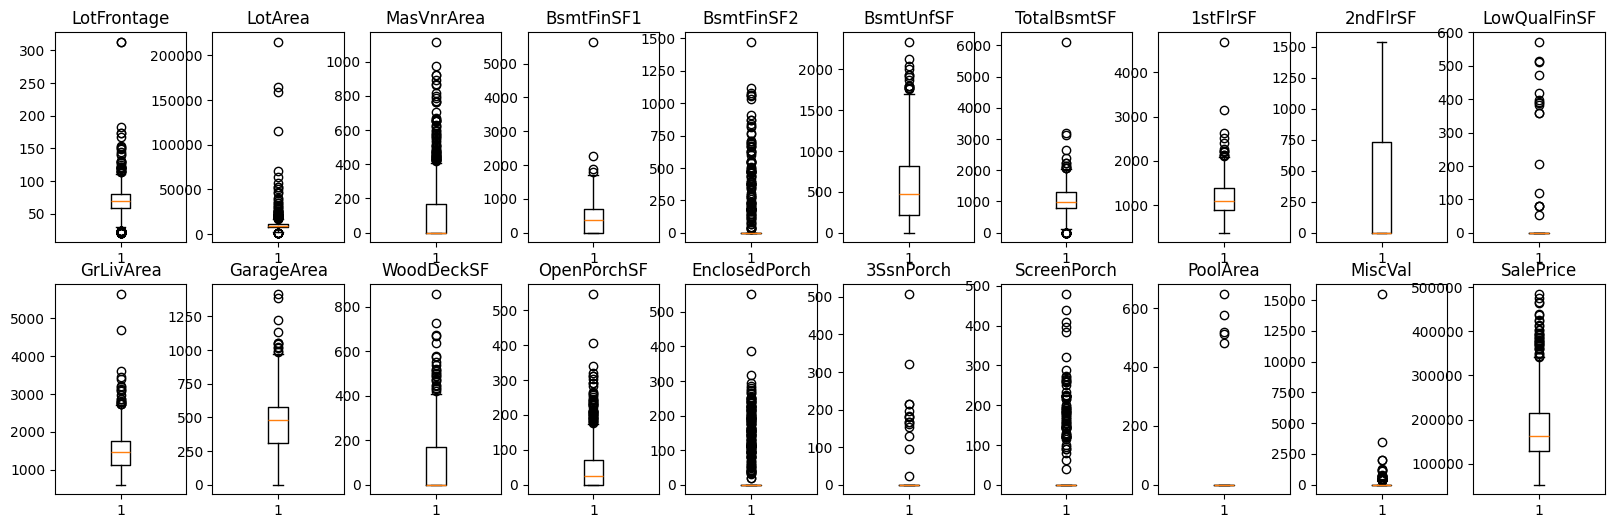

In [14]:
# ### Visualize Distributions of Numerical Columns (Training Data) ### #
fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(20.0, 6.0))

for i in range(len(numerical_columns)):
    axes[i // 10, i % 10].set_title(numerical_columns[i])
    axes[i // 10, i % 10].boxplot(train_df[numerical_columns[i]].dropna())


## Summary Table: Data Information and Modification Decisions

All the information and modification decisions derived from these preprocessing steps are summarized in this table. (As noted, the imputation of "LotFrontage" and exclusion of outliers will be explored further during the model tuning stage.)

id | column        | dtype   | # of null(train) | num | modify  | outlier |
---|---------------|:-------:|:----------------:|:---:|:-------:|:-------:|
1  | Id            | int64   | 0                | -   | -       |         |
2  | MSSubClass    | int64   | 0                |     |         |         |
3  | MSZoning      | object  | 0                |     |         |         |
4  | LotFrontage   | float64 | 259(186)         | T   | "LotArea" * 0.01 (in the tuning step)                                                | <= 200  |
5  | LotArea       | int64   | 0                | T   |         | <= 100000|
6  | Street        | object  | 0                |     |         |         |
7  | Alley         | object  | 1356(934)        |     | null -> "NA" |    |
8  | LotShape      | object  | 0                |     |         |         |
9  | LandContour   | object  | 0                |     |         |         |
10 | Utilities     | object  | 0                |     |         |         |
11 | LotConfig     | object  | 0                |     |         |         |
12 | LandSlope     | object  | 0                |     |         |         |
13 | Neighborhood  | object  | 0                |     |         |         |
14 | Condition1    | object  | 0                |     |         |         |
15 | Condition2    | object  | 0                |     |         |         |
16 | BldgType      | object  | 0                |     | (Keep "Twnhs")|   |
17 | HouseStyle    | object  | 0                |     |         |         |
18 | OverallQual   | int64   | 0                |     |         |         |
19 | OverallCond   | int64   | 0                |     |         |         |
20 | YearBuilt     | int64   | 0                |     |         |         |
21 | YearRemodAdd  | int64   | 0                |     |         |         |
22 | RoofStyle     | object  | 0                |     |         |         |
23 | RoofMatl      | object  | 0                |     |         |         |
24 | Exterior1st   | object  | 0                |     |         |         |
25 | Exterior2nd   | object  | 0                |     | "Brk Cmn" -> "BrkComm", "CmentBd" -> "CemntBd", "Wd Shng" -> "Wd Sdng"                  |         |
26 | MasVnrType    | object  | 866(596)         |     | null -> "None" |  |
27 | MasVnrArea    | float64 | 8(6)             | T   | null -> 0 | -     |
28 | ExterQual     | object  | 0                |     |         |         |
29 | ExterCond     | object  | 0                |     |         |         |
30 | Foundation    | object  | 0                |     |         |         |
31 | BsmtQual      | object  | 36(25)           |     | null -> "NA" |    |
32 | BsmtCond      | object  | 36(25)           |     | null -> "NA" |    |
33 | BsmtExposure  | object  | 37(26)           |     | null -> "NA" |    |
34 | BsmtFinType1  | object  | 36(25)           |     | null -> "NA" |    |
35 | BsmtFinSF1    | int64   | 0                | T   |         | <= 3000 |
36 | BsmtFinType2  | object  | 37(26)           |     | null -> "NA" |    |
37 | BsmtFinSF2    | int64   | 0                | T   |         | <= 1200 |
38 | BsmtUnfSF     | int64   | 0                | T   |         | -       |
39 | TotalBsmtSF   | int64   | 0                | T   |         | <= 4000 |
40 | Heating       | object  | 0                |     |         |         |
41 | HeatingQC     | object  | 0                |     |         |         |
42 | CentralAir    | object  | 0                |     |         |         |
43 | Electrical    | object  | 1(1)             |     | null -> "NA" |    |
44 | 1stFlrSF      | int64   | 0                | T   |         | <= 3200 |
45 | 2ndFlrSF      | int64   | 0                | T   |         | -       |
46 | LowQualFinSF  | int64   | 0                | T   |         | -       |
47 | GrLivArea     | int64   | 0                | T   |         | <= 4000 |
48 | BsmtFullBath  | int64   | 0                |     |         |         |
49 | BsmtHalfBath  | int64   | 0                |     |         |         |
50 | FullBath      | int64   | 0                |     |         |         |
51 | HalfBath      | int64   | 0                |     |         |         |
52 | BedroomAbvGr  | int64   | 0                |     |         |         |
53 | KitchenAbvGr  | int64   | 0                |     |         |         |
54 | KitchenQual   | object  | 0                |     |         |         |
55 | TotRmsAbvGrd  | int64   | 0                |     |         |         |
56 | Functional    | object  | 0                |     |         |         |
57 | Fireplaces    | int64   | 0                |     |         |         |
58 | FireplaceQu   | object  | 685(465)         |     | null -> "NA" |    |
59 | GarageType    | object  | 78(61)           |     | null -> "NA" |    |
60 | GarageYrBlt   | float64 | 78(61)           |     | float -> int, null -> 0  |   |
61 | GarageFinish  | object  | 78(61)           |     | null -> "NA" |    |
62 | GarageCars    | int64   | 0                |     |         |         |
63 | GarageArea    | int64   | 0                | T   |         |         |
64 | GarageQual    | object  | 78(61)           |     | null -> "NA" |    |
65 | GarageCond    | object  | 78(61)           |     | null -> "NA" |    |
66 | PavedDrive    | object  | 0                |     |         |         |
67 | WoodDeckSF    | int64   | 0                | T   |         | -       |
68 | OpenPorchSF   | int64   | 0                | T   |         | <= 350  |
69 | EnclosedPorch | int64   | 0                | T   |         | <= 350  |
70 | 3SsnPorch     | int64   | 0                | T   |         | <= 400  |
71 | ScreenPorch   | int64   | 0                | T   |         | -       |
72 | PoolArea      | int64   | 0                | T   |         | -       |
73 | PoolQC        | object  | 1440(995)        |     | null -> "NA" |    |
74 | Fence         | object  | 1169(815)        |     | null -> "NA" |    |
75 | MiscFeature   | object  | 1392(964)        |     | null -> "NA" |    |
76 | MiscVal       | int64   | 0                | T   |         | <= 4000 |
77 | MoSold        | int64   | 0                |     |         |         |
78 | YrSold        | int64   | 0                |     |         |         |
79 | SaleType      | object  | 0                |     |         |         |
80 | SaleCondition | object  | 0                |     |         |         |
81 | SalePrice     | int64   | 0                |     |         |         |



## Step 6

Modify the dataset based on the decisions made in the previous steps.
At this stage, transformations are applied according to the preprocessing plan, except for the imputation of "LotFrontage" and the removal of outliers, which will be handled later in the model tuning section.

In [15]:
# ### Modify Data Values Based on Review Results ### #
modified_mix_df = mix_df.copy()

# Fill NAs.
modified_mix_df = modified_mix_df.fillna(
    {
        "Alley": "NA",
        "MasVnrType": "None",
        "MasVnrArea": 0,
        "BsmtQual": "NA",
        "BsmtCond": "NA",
        "BsmtExposure": "NA",
        "BsmtFinType1": "NA",
        "BsmtFinType2": "NA",
        "Electrical": "NA",
        "FireplaceQu": "NA",
        "GarageType": "NA",
        "GarageYrBlt": 0,
        "GarageFinish": "NA",
        "GarageQual": "NA",
        "GarageCond": "NA",
        "PoolQC": "NA",
        "Fence": "NA",
        "MiscFeature": "NA"
    }
)

# Change the dtype of column "GarageYrBlt" from float64 into int64.
modified_mix_df["GarageYrBlt"] = modified_mix_df["GarageYrBlt"].astype("int64")

# Modify the values of column "Exterior2nd".
modified_mix_df["Exterior2nd"] = modified_mix_df["Exterior2nd"].str.replace("Brk Cmn", "BrkComm")
modified_mix_df["Exterior2nd"] = modified_mix_df["Exterior2nd"].str.replace("CmentBd", "CemntBd")
modified_mix_df["Exterior2nd"] = modified_mix_df["Exterior2nd"].str.replace("Wd Shng", "Wd Sdng")

print(f"### modified_mix_df ###\n{modified_mix_df}\n")

### modified_mix_df ###
        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0      149          20       RL         63.0     7500   Pave    NA      Reg   
1      460          50       RL          NaN     7015   Pave    NA      IR1   
2     1336          20       RL         80.0     9650   Pave    NA      Reg   
3      805          20       RL         75.0     9000   Pave    NA      Reg   
4     1396          60       RL         88.0    12665   Pave    NA      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1441  1456          60       RL         62.0     7917   Pave    NA      Reg   
1442  1457          20       RL         85.0    13175   Pave    NA      Reg   
1443  1458          70       RL         66.0     9042   Pave    NA      Reg   
1444  1459          20       RL         68.0     9717   Pave    NA      Reg   
1445  1460          20       RL         75.0     9937   Pave    NA      Reg   

     LandContour Utilities 

In [16]:
# ### Evaluate Modified Data ### #
evaluate_data(target_df=modified_mix_df)

MSSubClass 
 Series([], Name: MSSubClass, dtype: int64) 

MSZoning 
 Series([], Name: MSZoning, dtype: object) 

Street 
 Series([], Name: Street, dtype: object) 

Alley 
 Series([], Name: Alley, dtype: object) 

LotShape 
 Series([], Name: LotShape, dtype: object) 

LandContour 
 Series([], Name: LandContour, dtype: object) 

Utilities 
 Series([], Name: Utilities, dtype: object) 

LotConfig 
 Series([], Name: LotConfig, dtype: object) 

LandSlope 
 Series([], Name: LandSlope, dtype: object) 

Neighborhood 
 Series([], Name: Neighborhood, dtype: object) 

Condition1 
 Series([], Name: Condition1, dtype: object) 

Condition2 
 Series([], Name: Condition2, dtype: object) 

BldgType 
 10      Twnhs
29      Twnhs
54      Twnhs
126     Twnhs
130     Twnhs
200     Twnhs
222     Twnhs
226     Twnhs
233     Twnhs
310     Twnhs
345     Twnhs
349     Twnhs
373     Twnhs
398     Twnhs
594     Twnhs
634     Twnhs
635     Twnhs
662     Twnhs
679     Twnhs
690     Twnhs
715     Twnhs
717     Twnhs


# Modelling and Model Tuning

For this project, I select multiple linear regression as the predictive model.
The potential predictor variables are drawn from the dataset's columns. Numerical features are used directly, while categorical features are converted into one-hot encoded vectors to ensure compatibility with the regression model.

Since all columns are retained and approximately three-quarters of them are categorical, the forward selection process requires significant computation time (nearly a full day). Consequently, the number of experiments I can perform is limited. As discussed in the Data Preprocessing section, I conduct three tuning experiments based on the forward selection results obtained from the current dataset:

<br>&nbsp; **Experiment 1.** &nbsp; Run forward selection with the current preprocessed data (excluding the "LotFrontage" column, as its missing values have not been handled).
<br>&nbsp; **Experiment 2.** &nbsp; Impute missing values in the "LotFrontage" column.
<br>&nbsp; **Experiment 3.** &nbsp; Remove outliers as defined in the preprocessing phase.

<br>

The model achieving the best performance across these experiments will be selected as the final model. Before starting the experiments, I set up several common utility functions to streamline the evaluation and selection process.

In [23]:
# ### Prepare a one hot encoder ### #
encoder = OneHotEncoder(sparse_output=False)

# ### Set Up Forward Selection Function ### #
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
model = LinearRegression()


class ScoresByColumns(BaseModel):
    num_samples: int
    columns: list[str]
    scores_nrmse: list[float]
    scores_r2: list[float]

    @computed_field
    @property
    def avg_nrmse(self) -> float:
        return sum(self.scores_nrmse) / len(self.scores_nrmse)

    @computed_field
    @property
    def avg_adjr2(self) -> float:
        scores_adjr2: list[float] = []
        for i in self.scores_r2:
            scores_adjr2.append(
                1 - ((1 - i) * (self.num_samples - 1) / (self.num_samples - len(self.columns) - 1))
            )
        return sum(scores_adjr2) / len(scores_adjr2)


def forward(
    current_best_columns: list[str],
    X_train_df: pd.DataFrame,
    y_train_df: pd.Series,
) -> list[ScoresByColumns]:
    results: list[ScoresByColumns] = []

    # Pull out predictors we still need to process
    remaining_columns = [
        c for c in X_train_df.columns if c not in current_best_columns
    ]
    for c in remaining_columns:
        target_columns = current_best_columns + [c]
        scores_nrmse = cross_val_score(
            model,
            X_train_df[target_columns],
            y_train_df,
            cv=kf,
            scoring="neg_root_mean_squared_error"
        )
        scores_r2 = cross_val_score(
            model,
            X_train_df[target_columns],
            y_train_df,
            cv=kf,
            scoring="r2"
        )
        results.append(
            ScoresByColumns(
                num_samples=len(X_train_df),
                columns=target_columns,
                scores_nrmse=scores_nrmse.tolist(),
                scores_r2=scores_r2.tolist()
            )
        )
    return results

def run_forward(
    X_train_df: pd.DataFrame,
    y_train_df: pd.Series,
    current_best_columns: list[str]
) -> tuple[list[ScoresByColumns], list[ScoresByColumns]]:
    forward_all_list: list[ScoresByColumns] = []
    forward_best_list: list[ScoresByColumns] = []

    for i in range(len(X_train_df.columns) - len(current_best_columns)):
        forward_results = forward(
            current_best_columns=current_best_columns,
            X_train_df=X_train_df,
            y_train_df=y_train_df
        )
        forward_all_list += forward_results
        forward_best_list.append(max(forward_results, key=lambda item: item.avg_nrmse))
        current_best_columns.append(forward_best_list[-1].columns[-1])
        print(
            f"{str(len(forward_best_list[-1].columns)).zfill(3)} " +
            f"{round(forward_best_list[-1].avg_nrmse) * (-1)} " +
            f"{forward_best_list[-1].avg_adjr2:.4f} " +
            f"{forward_best_list[-1].columns}"
        )
    return forward_all_list, forward_best_list

def plot_rmse(rmse_list: list[float], plot_title: str) -> None:
    rmse_min: float = min(rmse_list)
    rmse_min_index: int = np.argmin(rmse_list)
    # print(f"RMSE-min: {rmse_min} (columns: {rmse_min_index + 1})")

    plt.plot(rmse_list)
    plt.title(plot_title)
    plt.text(
        50,
        50000,
        f"RMSE-min: {rmse_min}, columns: {rmse_min_index + 1}",
        fontsize=10,
        color="black"
    )
    plt.xlabel("# Features (Predictors)")
    plt.ylabel("Average Validate RSME of 5-Fold CV")
    plt.plot(rmse_min_index, rmse_min, "or");

def predict_test_prices(
    features_best: list[str],
    X_train_df: pd.DataFrame,
    y_train_df: pd.Series,
    X_test_df: pd.DataFrame
) -> list[int]:
    # Fit the model
    model.fit(X_train_df[features_best], y_train_df)
    print(f"intercept: {model.intercept_}")
    print(f"coefficients: {model.coef_}")

    # Predict the SalePrices for the test dataset
    predictions = model.predict(X_test_df[features_best])

    #Convert the predictions to a LIST of POSITIVE INTEGERS (do not submit decimals!)
    list_predictions: list[float] = predictions.tolist()
    rounded_list_predictions: list[int] = [int(x) for x in list_predictions]
    print(f"predictions: {rounded_list_predictions}")

    return rounded_list_predictions

## Experiment 1: Current Preprocessed Data
In the first experiment, forward selection is applied to the current preprocessed dataset. The "LotFrontage" column is excluded because its missing values have not yet been imputed.

In [18]:
# ### Encode Categorical Columns ### #
# One Hot Encoding
one_hot_encoded_1 = encoder.fit_transform(modified_mix_df[categorical_columns])
one_hot_df_1 = pd.DataFrame(
    one_hot_encoded_1,
    columns=encoder.get_feature_names_out(categorical_columns)
)

transformed_mix_df_1 = pd.concat(
    [
        modified_mix_df.drop(categorical_columns + ["SalePrice", "LotFrontage"], axis=1),
        one_hot_df_1,
        modified_mix_df["SalePrice"]
    ],
    axis=1
)

print(f"### transformed_mix_df_1 ###\n{transformed_mix_df_1}\n")

### transformed_mix_df_1 ###
        Id  LotArea  MasVnrArea  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  \
0      149     7500       120.0         680           0        400   
1      460     7015       161.0         185           0        524   
2     1336     9650       360.0         686           0        664   
3      805     9000         0.0         812           0        124   
4     1396    12665       245.0           0           0       1094   
...    ...      ...         ...         ...         ...        ...   
1441  1456     7917         0.0           0           0        953   
1442  1457    13175       119.0         790         163        589   
1443  1458     9042         0.0         275           0        877   
1444  1459     9717         0.0          49        1029          0   
1445  1460     9937         0.0         830         290        136   

      TotalBsmtSF  1stFlrSF  2ndFlrSF  LowQualFinSF  ...  SaleType_New  \
0            1080      1080         0             0  ...

In [19]:
# ### Split Combined Dataset into Train and Test Sets ### #
X_train_df_1 = transformed_mix_df_1.iloc[:1000, 1:653]
y_train_df_1 = transformed_mix_df_1.iloc[:1000, 653]
X_test_df_1 = transformed_mix_df_1.iloc[1000:1446, 1:653]
y_test_df_1 = transformed_mix_df_1.iloc[1000:1446, 653]

print(f"### X_train_df_1 ###\n{X_train_df_1}\n")
print(f"### y_train_df_1 ###\n{y_train_df_1}\n")
print(f"### X_test_df_1 ###\n{X_test_df_1}\n")
print(f"### y_test_df_1 ###\n{y_test_df_1}\n")

### X_train_df_1 ###
     LotArea  MasVnrArea  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  \
0       7500       120.0         680           0        400         1080   
1       7015       161.0         185           0        524          709   
2       9650       360.0         686           0        664         1350   
3       9000         0.0         812           0        124          936   
4      12665       245.0           0           0       1094         1094   
..       ...         ...         ...         ...        ...          ...   
995     9286         0.0         196           0       1072         1268   
996     2001        80.0           0           0        546          546   
997     8967         0.0           0           0        961          961   
998     5000         0.0         218           0        808         1026   
999    10356         0.0         716           0        253          969   

     1stFlrSF  2ndFlrSF  LowQualFinSF  GrLivArea  ...  SaleType_Co

In [ ]:
# ### Run Forward Selection ### #
current_best_columns_1: list[str] = []

forward_all_list_1, forward_best_list_1 = run_forward(
    X_train_df=X_train_df_1,
    y_train_df=y_train_df_1,
    current_best_columns=current_best_columns_1
)

The forward selection provided the result that **222 features** model achieved the best **validation RMSE 23270**. (Due to computational constraints, the forward selection was stopped once the minimum RMSE was observed.) After fitting the linear regression model with the full training dataset, the test score is **?????**.

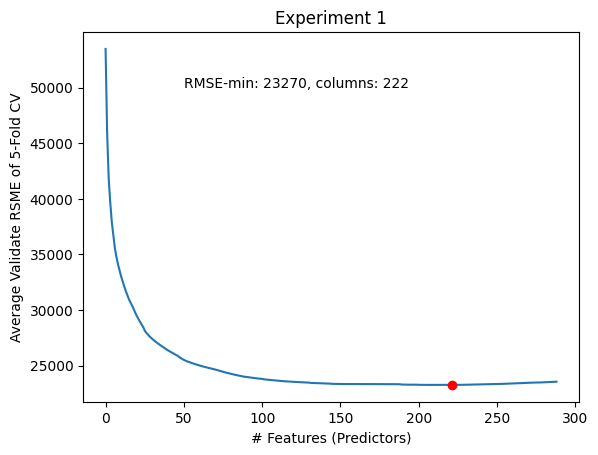

In [24]:
rmse_list_1: list[float] = [53477, 45913, 41817, 39652, 37883, 36708, 35500, 34732, 34074, 33536, 32992, 32542, 32096, 31679, 31317, 30944, 30653, 30379, 30085, 29743, 29458, 29189, 28942, 28698, 28479, 28164, 27958, 27810, 27645, 27512, 27384, 27262, 27147, 27042, 26942, 26835, 26739, 26648, 26545, 26452, 26364, 26285, 26207, 26130, 26052, 25964, 25886, 25785, 25694, 25599, 25525, 25452, 25392, 25345, 25300, 25249, 25194, 25144, 25106, 25069, 25021, 24977, 24936, 24902, 24868, 24831, 24794, 24759, 24724, 24691, 24654, 24613, 24577, 24526, 24489, 24453, 24418, 24375, 24339, 24300, 24267, 24235, 24203, 24172, 24140, 24111, 24078, 24051, 24022, 24002, 23983, 23966, 23946, 23928, 23912, 23888, 23867, 23852, 23839, 23826, 23802, 23780, 23760, 23746, 23732, 23718, 23706, 23696, 23683, 23667, 23645, 23629, 23618, 23609, 23600, 23591, 23583, 23575, 23566, 23558, 23551, 23543, 23536, 23529, 23517, 23510, 23505, 23499, 23492, 23486, 23476, 23452, 23446, 23439, 23431, 23425, 23420, 23415, 23411, 23406, 23400, 23397, 23393, 23390, 23373, 23364, 23361, 23357, 23355, 23353, 23352, 23350, 23349, 23349, 23348, 23348, 23347, 23346, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23345, 23344, 23342, 23339, 23336, 23334, 23333, 23332, 23332, 23304, 23300, 23297, 23294, 23293, 23291, 23292, 23292, 23293, 23292, 23283, 23279, 23277, 23275, 23272, 23272, 23272, 23271, 23271, 23271, 23271, 23271, 23271, 23271, 23271, 23272, 23274, 23273, 23273, 23273, 23274, 23275, 23270, 23270, 23272, 23274, 23274, 23275, 23278, 23280, 23283, 23286, 23289, 23293, 23296, 23300, 23304, 23307, 23311, 23313, 23317, 23321, 23325, 23329, 23330, 23332, 23334, 23335, 23340, 23345, 23350, 23356, 23359, 23360, 23360, 23367, 23373, 23379, 23386, 23392, 23399, 23405, 23409, 23415, 23422, 23429, 23436, 23443, 23449, 23456, 23463, 23471, 23471, 23479, 23488, 23488, 23488, 23488, 23492, 23492, 23498, 23505, 23505, 23512, 23519, 23526, 23536, 23543, 23553, 23564]
# rmse_list_1: list[float] = [i.avg_nrmse * (-1) for i in forward_best_list_1]

plot_rmse(rmse_list=rmse_list_1, plot_title="Experiment 1")

In [43]:
# ### Predict the test prices ### #
features_best_1: list[str] = ['GrLivArea', 'ExterQual_TA', 'GarageCars_3', 'GarageType_Attchd', 'BsmtQual_Ex', 'Fireplaces_2', 'BsmtQual_Gd', 'MSSubClass_20', 'KitchenQual_Ex', 'BsmtExposure_Gd', 'KitchenAbvGr_1', 'GarageCars_2', 'Functional_Typ', 'Condition1_Norm', 'Fireplaces_1', 'BsmtFinType1_GLQ', 'OverallCond_3', 'Neighborhood_NridgHt', 'Neighborhood_Crawfor', 'Neighborhood_NoRidge', 'RoofMatl_WdShngl', 'Neighborhood_StoneBr', 'LotConfig_CulDSac', 'Exterior1st_BrkFace', 'Neighborhood_Somerst', 'BldgType_1Fam', 'SaleCondition_Abnorml', 'YearBuilt_1892', 'RoofMatl_ClyTile', 'OverallQual_9', 'GarageYrBlt_2006', 'LotShape_IR2', 'OverallCond_7', 'KitchenQual_Fa', 'MSZoning_RL', 'OverallCond_8', 'Exterior2nd_VinylSd', 'Neighborhood_Edwards', 'BsmtFullBath_0', 'SaleType_WD', 'FireplaceQu_Gd', 'GarageQual_Ex', 'Neighborhood_NAmes', 'GarageQual_TA', 'ScreenPorch', 'YearBuilt_1963', 'OverallQual_8', 'WoodDeckSF', 'OverallQual_7', 'YrSold_2008', 'TotRmsAbvGrd_12', 'YearBuilt_1932', 'GarageCars_4', 'Neighborhood_MeadowV', 'Neighborhood_OldTown', 'YearRemodAdd_2002', 'OverallCond_9', 'YearBuilt_1989', 'LotShape_Reg', 'HalfBath_1', 'GarageType_2Types', 'BldgType_Twnhs', 'MoSold_7', 'YearRemodAdd_1999', 'YrSold_2009', 'GarageYrBlt_1975', 'BedroomAbvGr_3', 'YearRemodAdd_1997', 'GarageYrBlt_1957', 'YearRemodAdd_2003', 'SaleType_COD', 'Condition1_RRAn', 'BsmtExposure_No', 'BsmtExposure_NA', 'BsmtCond_Fa', 'Neighborhood_SawyerW', 'FireplaceQu_Ex', 'FullBath_2', 'MoSold_10', 'OverallCond_6', 'BsmtFinType1_Unf', 'GarageYrBlt_1923', 'YearBuilt_1952', 'MSSubClass_80', 'YearBuilt_2001', 'LotConfig_FR3', 'HouseStyle_2.5Unf', 'YearRemodAdd_2004', 'Electrical_SBrkr', 'Condition1_RRAe', 'YearRemodAdd_1962', 'PavedDrive_P', 'SaleCondition_AdjLand', 'GarageYrBlt_1934', 'YearBuilt_1986', 'Exterior1st_VinylSd', 'MSSubClass_70', 'YearBuilt_1973', 'Exterior1st_AsbShng', 'LandContour_Bnk', 'YearBuilt_1930', 'GarageYrBlt_1969', 'LandSlope_Gtl', 'GarageYrBlt_1948', 'YearBuilt_1900', 'GarageYrBlt_1952', 'OverallQual_3', 'YearBuilt_1991', 'TotRmsAbvGrd_9', 'TotRmsAbvGrd_7', 'YearBuilt_1984', 'Utilities_NoSeWa', 'YearBuilt_1910', 'YearRemodAdd_1960', 'YearRemodAdd_1963', 'TotRmsAbvGrd_3', 'GarageYrBlt_1947', 'GarageQual_Gd', 'ExterQual_Gd', 'Condition1_RRNe', 'SaleCondition_Normal', 'GarageYrBlt_1950', 'SaleType_ConLI', 'YearBuilt_1913', 'YearBuilt_1904', 'YearBuilt_1940', 'YearBuilt_1976', 'PoolQC_Fa', 'YearBuilt_1924', 'GarageYrBlt_1915', 'RoofStyle_Gambrel', 'YearBuilt_1925', 'Neighborhood_Sawyer', 'GarageYrBlt_1940', 'YearRemodAdd_1985', 'BsmtFinSF2', 'GarageCond_TA', 'YearBuilt_1996', 'OverallQual_5', 'YearRemodAdd_1950', 'YearBuilt_1885', 'YearBuilt_1959', 'YearRemodAdd_2001', 'GarageYrBlt_1991', 'GarageYrBlt_1959', 'YearBuilt_1929', 'HeatingQC_Gd', 'GarageYrBlt_1924', 'MiscFeature_Gar2', 'FireplaceQu_TA', 'FireplaceQu_Fa', 'Condition2_Artery', 'YearRemodAdd_1953', 'GarageYrBlt_1981', 'KitchenAbvGr_3', 'YearBuilt_1977', 'YearRemodAdd_1972', 'YearBuilt_1937', 'GarageYrBlt_1939', 'YearRemodAdd_1961', 'GarageYrBlt_2001', 'GarageYrBlt_1973', 'Utilities_AllPub', 'GarageYrBlt_1984', 'YearRemodAdd_1952', 'MSSubClass_40', 'Condition2_PosA', 'Condition2_RRAe', 'Condition2_RRAn', 'Condition2_RRNn', 'YearBuilt_1893', 'YearBuilt_1905', 'YearBuilt_1912', 'YearBuilt_1917', 'YearBuilt_1983', 'YearBuilt_2010', 'RoofStyle_Shed', 'BsmtFullBath_3', 'Functional_Sev', 'RoofMatl_Roll', 'Functional_Min1', 'YearBuilt_1970', 'Neighborhood_BrDale', 'TotRmsAbvGrd_8', 'HouseStyle_SFoyer', 'YearRemodAdd_1971', 'BsmtQual_NA', 'Neighborhood_Blueste', 'YearRemodAdd_1958', 'YearBuilt_1958', 'SaleType_ConLw', 'GarageYrBlt_1970', 'Heating_Floor', 'Fence_GdWo', 'GarageYrBlt_1954', 'BsmtCond_NA', 'BsmtFinType1_NA', 'YearRemodAdd_1992', 'Foundation_BrkTil', 'YearBuilt_1935', 'GarageYrBlt_1936', 'YearRemodAdd_1995', 'YearBuilt_1995', 'RoofStyle_Mansard', 'LandContour_HLS', 'BsmtFinType1_BLQ', 'HouseStyle_SLvl', 'YearBuilt_1954', 'GarageYrBlt_1961', 'GarageYrBlt_1933', 'GarageYrBlt_1982', 'MoSold_5', 'MoSold_3', 'Exterior2nd_AsphShn', 'SaleCondition_Alloca', 'Electrical_Mix', 'GarageYrBlt_1920', 'ExterCond_Gd', 'GarageType_CarPort', 'YearRemodAdd_1968', 'MSZoning_C (all)', 'BsmtFinType1_Rec', 'YearBuilt_2003']
predictions_list_1: list[int] = predict_test_prices(
    features_best=features_best_1,
    X_train_df=X_train_df_1,
    y_train_df=y_train_df_1,
    X_test_df=X_test_df_1
)

intercept: 59535.447369885354
coefficients: [ 4.28940679e+01 -1.56789345e+04  2.60474443e+04  3.29557111e+03
  1.45682423e+04  2.48486385e+04  2.31341302e+03  1.57263757e+04
  1.85626400e+04  1.75161420e+04  1.60847747e+03  9.14059899e+03
  1.32831645e+04  1.10566162e+04  9.52743584e+03  5.93456203e+03
 -2.06909769e+04  3.67609444e+04  2.16368745e+04  3.45166205e+04
  7.23708407e+04  4.04934031e+04  1.16183649e+04  1.96227991e+04
  1.48655784e+04  8.03049331e+03 -6.77747188e+03  7.89532399e+04
 -2.15795882e+05  4.47648141e+04  9.21864988e+03  1.30539418e+04
  1.51094965e+04 -9.10684961e+03  1.63988140e+03  1.62779003e+04
  2.45696652e+04 -1.68949735e+04 -1.09323403e+04 -2.34235717e+04
 -6.16898659e+03  2.82255898e+04 -1.07039843e+04  1.27820612e+03
  4.06305809e+01 -3.08478754e+03  2.50663941e+04  2.60329764e+01
  9.77037271e+03  1.80156186e+03 -1.30991114e+04  3.27500572e+04
  3.47434971e+04 -1.64019868e+04 -1.02316056e+04  8.79134244e+03
  2.03813149e+04  1.94679033e+04  4.01174182e+

## Experiment 2: Impute the LotFrontage Column

Next, I evaluate the effect of imputing missing values in the "LotFrontage" column on model performance.

In [25]:
# ### Modify Data Values Based on Review Results ### #
modified_mix_df_2 = modified_mix_df.copy()

# Fill NAs.
modified_mix_df_2 = modified_mix_df_2.fillna(
    {
        "LotFrontage": modified_mix_df_2["LotArea"] * 0.01,
    }
)

print(f"### modified_mix_df_2 ###\n{modified_mix_df_2}\n")

### modified_mix_df_2 ###
        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0      149          20       RL        63.00     7500   Pave    NA      Reg   
1      460          50       RL        70.15     7015   Pave    NA      IR1   
2     1336          20       RL        80.00     9650   Pave    NA      Reg   
3      805          20       RL        75.00     9000   Pave    NA      Reg   
4     1396          60       RL        88.00    12665   Pave    NA      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1441  1456          60       RL        62.00     7917   Pave    NA      Reg   
1442  1457          20       RL        85.00    13175   Pave    NA      Reg   
1443  1458          70       RL        66.00     9042   Pave    NA      Reg   
1444  1459          20       RL        68.00     9717   Pave    NA      Reg   
1445  1460          20       RL        75.00     9937   Pave    NA      Reg   

     LandContour Utilitie

In [26]:
# ### Encode Categorical Columns ### #
# One Hot Encoding
one_hot_encoded_2 = encoder.fit_transform(modified_mix_df_2[categorical_columns])
one_hot_df_2 = pd.DataFrame(
    one_hot_encoded_2,
    columns=encoder.get_feature_names_out(categorical_columns)
)

transformed_mix_df_2 = pd.concat(
    [
        modified_mix_df_2.drop(categorical_columns + ["SalePrice"], axis=1),
        one_hot_df_2,
        modified_mix_df_2["SalePrice"]
    ],
    axis=1
)

print(f"### transformed_mix_df_2 ###\n{transformed_mix_df_2}\n")

### transformed_mix_df_2 ###
        Id  LotFrontage  LotArea  MasVnrArea  BsmtFinSF1  BsmtFinSF2  \
0      149        63.00     7500       120.0         680           0   
1      460        70.15     7015       161.0         185           0   
2     1336        80.00     9650       360.0         686           0   
3      805        75.00     9000         0.0         812           0   
4     1396        88.00    12665       245.0           0           0   
...    ...          ...      ...         ...         ...         ...   
1441  1456        62.00     7917         0.0           0           0   
1442  1457        85.00    13175       119.0         790         163   
1443  1458        66.00     9042         0.0         275           0   
1444  1459        68.00     9717         0.0          49        1029   
1445  1460        75.00     9937         0.0         830         290   

      BsmtUnfSF  TotalBsmtSF  1stFlrSF  2ndFlrSF  ...  SaleType_New  \
0           400         1080      1

In [27]:
# ### Split Combined Dataset into Train and Test Sets ### #
X_train_df_2 = transformed_mix_df_2.iloc[:1000, 1:654]
y_train_df_2 = transformed_mix_df_2.iloc[:1000, 654]
X_test_df_2 = transformed_mix_df_2.iloc[1000:1446, 1:654]
y_test_df_2 = transformed_mix_df_2.iloc[1000:1446, 654]

print(f"### X_train_df_2 ###\n{X_train_df_2}\n")
print(f"### y_train_df_2 ###\n{y_train_df_2}\n")
print(f"### X_test_df_2 ###\n{X_test_df_2}\n")
print(f"### y_test_df_2 ###\n{y_test_df_2}\n")

### X_train_df_2 ###
     LotFrontage  LotArea  MasVnrArea  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  \
0          63.00     7500       120.0         680           0        400   
1          70.15     7015       161.0         185           0        524   
2          80.00     9650       360.0         686           0        664   
3          75.00     9000         0.0         812           0        124   
4          88.00    12665       245.0           0           0       1094   
..           ...      ...         ...         ...         ...        ...   
995        92.86     9286         0.0         196           0       1072   
996        21.00     2001        80.0           0           0        546   
997        60.00     8967         0.0           0           0        961   
998        50.00     5000         0.0         218           0        808   
999       120.00    10356         0.0         716           0        253   

     TotalBsmtSF  1stFlrSF  2ndFlrSF  LowQualFinSF  ...  SaleType_

In [38]:
# ### Run Forward Selection ### #
current_best_columns_2: list[str] = ['GrLivArea', 'ExterQual_TA', 'GarageCars_3', 'GarageType_Attchd', 'BsmtQual_Ex', 'Fireplaces_2', 'BsmtQual_Gd', 'MSSubClass_20', 'KitchenQual_Ex', 'BsmtExposure_Gd', 'KitchenAbvGr_1', 'GarageCars_2', 'Functional_Typ', 'Condition1_Norm', 'Fireplaces_1', 'BsmtFinType1_GLQ', 'OverallCond_3', 'Neighborhood_NridgHt', 'Neighborhood_Crawfor', 'Neighborhood_NoRidge', 'RoofMatl_WdShngl', 'Neighborhood_StoneBr', 'LotConfig_CulDSac', 'Exterior1st_BrkFace', 'Neighborhood_Somerst', 'BldgType_1Fam', 'SaleCondition_Abnorml', 'YearBuilt_1892', 'RoofMatl_ClyTile', 'OverallQual_9', 'GarageYrBlt_2006', 'LotShape_IR2', 'OverallCond_7', 'KitchenQual_Fa', 'MSZoning_RL', 'OverallCond_8', 'Exterior2nd_VinylSd', 'Neighborhood_Edwards', 'BsmtFullBath_0', 'SaleType_WD', 'FireplaceQu_Gd', 'GarageQual_Ex', 'Neighborhood_NAmes', 'GarageQual_TA', 'ScreenPorch', 'YearBuilt_1963', 'OverallQual_8', 'WoodDeckSF', 'OverallQual_7', 'YrSold_2008', 'TotRmsAbvGrd_12', 'YearBuilt_1932', 'GarageCars_4', 'Neighborhood_MeadowV', 'Neighborhood_OldTown', 'YearRemodAdd_2002', 'OverallCond_9', 'YearBuilt_1989', 'LotShape_Reg', 'HalfBath_1', 'GarageType_2Types', 'BldgType_Twnhs', 'MoSold_7', 'YearRemodAdd_1999', 'YrSold_2009', 'GarageYrBlt_1975', 'BedroomAbvGr_3', 'YearRemodAdd_1997', 'GarageYrBlt_1957', 'YearRemodAdd_2003', 'SaleType_COD', 'Condition1_RRAn', 'BsmtExposure_No', 'BsmtExposure_NA', 'BsmtCond_Fa', 'Neighborhood_SawyerW', 'FireplaceQu_Ex', 'FullBath_2', 'MoSold_10', 'OverallCond_6', 'BsmtFinType1_Unf', 'GarageYrBlt_1923', 'YearBuilt_1952', 'MSSubClass_80', 'YearBuilt_2001', 'LotConfig_FR3', 'HouseStyle_2.5Unf', 'YearRemodAdd_2004', 'Electrical_SBrkr', 'Condition1_RRAe', 'YearRemodAdd_1962', 'PavedDrive_P', 'SaleCondition_AdjLand', 'GarageYrBlt_1934', 'YearBuilt_1986', 'Exterior1st_VinylSd', 'MSSubClass_70', 'YearBuilt_1973', 'Exterior1st_AsbShng', 'LandContour_Bnk', 'YearBuilt_1930', 'GarageYrBlt_1969', 'LandSlope_Gtl', 'GarageYrBlt_1948', 'YearBuilt_1900', 'GarageYrBlt_1952', 'OverallQual_3', 'YearBuilt_1991', 'TotRmsAbvGrd_9', 'TotRmsAbvGrd_7', 'YearBuilt_1984', 'Utilities_NoSeWa', 'YearBuilt_1910', 'YearRemodAdd_1960', 'YearRemodAdd_1963', 'TotRmsAbvGrd_3', 'GarageYrBlt_1947', 'GarageQual_Gd', 'ExterQual_Gd', 'Condition1_RRNe', 'SaleCondition_Normal', 'GarageYrBlt_1950', 'SaleType_ConLI', 'YearBuilt_1913', 'YearBuilt_1904', 'YearBuilt_1940', 'YearBuilt_1976', 'PoolQC_Fa', 'YearBuilt_1924', 'GarageYrBlt_1915', 'RoofStyle_Gambrel', 'YearBuilt_1925', 'Neighborhood_Sawyer', 'GarageYrBlt_1940', 'YearRemodAdd_1985', 'BsmtFinSF2', 'GarageCond_TA', 'YearBuilt_1996', 'OverallQual_5', 'YearRemodAdd_1950']

forward_all_list_2, forward_best_list_2 = run_forward(
    X_train_df=X_train_df_2,
    y_train_df=y_train_df_2,
    current_best_columns=current_best_columns_2
)

141 23400 0.8723 ['GrLivArea', 'ExterQual_TA', 'GarageCars_3', 'GarageType_Attchd', 'BsmtQual_Ex', 'Fireplaces_2', 'BsmtQual_Gd', 'MSSubClass_20', 'KitchenQual_Ex', 'BsmtExposure_Gd', 'KitchenAbvGr_1', 'GarageCars_2', 'Functional_Typ', 'Condition1_Norm', 'Fireplaces_1', 'BsmtFinType1_GLQ', 'OverallCond_3', 'Neighborhood_NridgHt', 'Neighborhood_Crawfor', 'Neighborhood_NoRidge', 'RoofMatl_WdShngl', 'Neighborhood_StoneBr', 'LotConfig_CulDSac', 'Exterior1st_BrkFace', 'Neighborhood_Somerst', 'BldgType_1Fam', 'SaleCondition_Abnorml', 'YearBuilt_1892', 'RoofMatl_ClyTile', 'OverallQual_9', 'GarageYrBlt_2006', 'LotShape_IR2', 'OverallCond_7', 'KitchenQual_Fa', 'MSZoning_RL', 'OverallCond_8', 'Exterior2nd_VinylSd', 'Neighborhood_Edwards', 'BsmtFullBath_0', 'SaleType_WD', 'FireplaceQu_Gd', 'GarageQual_Ex', 'Neighborhood_NAmes', 'GarageQual_TA', 'ScreenPorch', 'YearBuilt_1963', 'OverallQual_8', 'WoodDeckSF', 'OverallQual_7', 'YrSold_2008', 'TotRmsAbvGrd_12', 'YearBuilt_1932', 'GarageCars_4', 'Neig

KeyboardInterrupt: 

The forward selection provided the result that **??? features** model achieved the best **validation RMSE ?????**. (Due to computational constraints, the forward selection was stopped once the minimum RMSE was observed.) After fitting the linear regression model with the full training dataset, the test score is **?????**.

Interestingly, the resulting model includes "LotFrontage" as a feature and has a slightly better performance than Experiment 1. Though it is a tiny improvement, I retain the imputed "LotFrontage" column in subsequent steps because it has a positive impact.

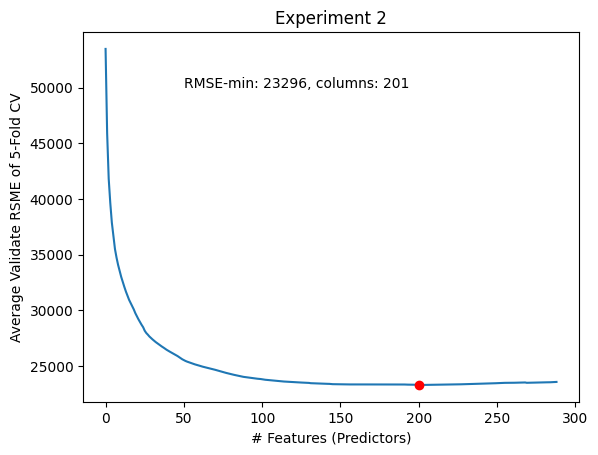

In [39]:
rmse_list_2: list[float] = [53477, 45913, 41817, 39652, 37883, 36708, 35500, 34732, 34074, 33536, 32992, 32542, 32096, 31679, 31317, 30944, 30653, 30379, 30085, 29743, 29458, 29189, 28942, 28698, 28479, 28164, 27958, 27810, 27645, 27512, 27384, 27262, 27147, 27042, 26942, 26835, 26739, 26648, 26545, 26452, 26364, 26285, 26207, 26130, 26052, 25964, 25886, 25785, 25694, 25599, 25525, 25452, 25392, 25345, 25300, 25249, 25194, 25144, 25106, 25069, 25021, 24977, 24936, 24902, 24868, 24831, 24794, 24759, 24724, 24691, 24654, 24613, 24577, 24526, 24489, 24453, 24418, 24375, 24339, 24300, 24267, 24235, 24203, 24172, 24140, 24111, 24078, 24051, 24022, 24002, 23983, 23966, 23946, 23928, 23912, 23888, 23867, 23852, 23839, 23826, 23802, 23780, 23760, 23746, 23732, 23718, 23706, 23696, 23683, 23667, 23645, 23629, 23618, 23609, 23600, 23591, 23583, 23575, 23566, 23558, 23551, 23543, 23536, 23529, 23517, 23510, 23505, 23499, 23492, 23486, 23476, 23452, 23446, 23439, 23431, 23425, 23420, 23415, 23411, 23406, 23400, 23397, 23393, 23390, 23373, 23364, 23361, 23356, 23352, 23349, 23348, 23346, 23344, 23342, 23341, 23340, 23340, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23339, 23340, 23340, 23340, 23341, 23342, 23342, 23340, 23340, 23336, 23335, 23333, 23325, 23322, 23319, 23315, 23309, 23304, 23299, 23297, 23296, 23296, 23297, 23297, 23298, 23300, 23300, 23301, 23303, 23304, 23307, 23309, 23311, 23314, 23313, 23316, 23318, 23320, 23323, 23326, 23329, 23333, 23336, 23340, 23344, 23348, 23348, 23352, 23356, 23361, 23365, 23370, 23375, 23379, 23384, 23388, 23394, 23399, 23403, 23408, 23409, 23410, 23414, 23420, 23424, 23429, 23429, 23435, 23441, 23447, 23454, 23461, 23468, 23475, 23475, 23483, 23483, 23484, 23484, 23488, 23488, 23491, 23496, 23502, 23505, 23510, 23510, 23516, 23517, 23487, 23491, 23494, 23497, 23499, 23504, 23502, 23506, 23511, 23516, 23522, 23529, 23536, 23531, 23530, 23535, 23542, 23549, 23557, 23565]
# rmse_list_2: list[float] = [i.avg_nrmse * (-1) for i in forward_best_list_2]

plot_rmse(rmse_list=rmse_list_2, plot_title="Experiment 2")

In [ ]:
# ### Predict the test prices ### #
features_best_2: list[str] = ['GrLivArea', 'ExterQual_TA', 'GarageCars_3', 'GarageType_Attchd', 'BsmtQual_Ex', 'Fireplaces_2', 'BsmtQual_Gd', 'MSSubClass_20', 'KitchenQual_Ex', 'BsmtExposure_Gd', 'KitchenAbvGr_1', 'GarageCars_2', 'Functional_Typ', 'Condition1_Norm', 'Fireplaces_1', 'BsmtFinType1_GLQ', 'OverallCond_3', 'Neighborhood_NridgHt', 'Neighborhood_Crawfor', 'Neighborhood_NoRidge', 'RoofMatl_WdShngl', 'Neighborhood_StoneBr', 'LotConfig_CulDSac', 'Exterior1st_BrkFace', 'Neighborhood_Somerst', 'BldgType_1Fam', 'SaleCondition_Abnorml', 'YearBuilt_1892', 'RoofMatl_ClyTile', 'OverallQual_9', 'GarageYrBlt_2006', 'LotShape_IR2', 'OverallCond_7', 'KitchenQual_Fa', 'MSZoning_RL', 'OverallCond_8', 'Exterior2nd_VinylSd', 'Neighborhood_Edwards', 'BsmtFullBath_0', 'SaleType_WD', 'FireplaceQu_Gd', 'GarageQual_Ex', 'Neighborhood_NAmes', 'GarageQual_TA', 'ScreenPorch', 'YearBuilt_1963', 'OverallQual_8', 'WoodDeckSF', 'OverallQual_7', 'YrSold_2008', 'TotRmsAbvGrd_12', 'YearBuilt_1932', 'GarageCars_4', 'Neighborhood_MeadowV', 'Neighborhood_OldTown', 'YearRemodAdd_2002', 'OverallCond_9', 'YearBuilt_1989', 'LotShape_Reg', 'HalfBath_1', 'GarageType_2Types', 'BldgType_Twnhs', 'MoSold_7', 'YearRemodAdd_1999', 'YrSold_2009', 'GarageYrBlt_1975', 'BedroomAbvGr_3', 'YearRemodAdd_1997', 'GarageYrBlt_1957', 'YearRemodAdd_2003', 'SaleType_COD', 'Condition1_RRAn', 'BsmtExposure_No', 'BsmtExposure_NA', 'BsmtCond_Fa', 'Neighborhood_SawyerW', 'FireplaceQu_Ex', 'FullBath_2', 'MoSold_10', 'OverallCond_6', 'BsmtFinType1_Unf', 'GarageYrBlt_1923', 'YearBuilt_1952', 'MSSubClass_80', 'YearBuilt_2001', 'LotConfig_FR3', 'HouseStyle_2.5Unf', 'YearRemodAdd_2004', 'Electrical_SBrkr', 'Condition1_RRAe', 'YearRemodAdd_1962', 'PavedDrive_P', 'SaleCondition_AdjLand', 'GarageYrBlt_1934', 'YearBuilt_1986', 'Exterior1st_VinylSd', 'MSSubClass_70', 'YearBuilt_1973', 'Exterior1st_AsbShng', 'LandContour_Bnk', 'YearBuilt_1930', 'GarageYrBlt_1969', 'LandSlope_Gtl', 'GarageYrBlt_1948', 'YearBuilt_1900', 'GarageYrBlt_1952', 'OverallQual_3', 'YearBuilt_1991', 'TotRmsAbvGrd_9', 'TotRmsAbvGrd_7', 'YearBuilt_1984', 'Utilities_NoSeWa', 'YearBuilt_1910', 'YearRemodAdd_1960', 'YearRemodAdd_1963', 'TotRmsAbvGrd_3', 'GarageYrBlt_1947', 'GarageQual_Gd', 'ExterQual_Gd', 'Condition1_RRNe', 'SaleCondition_Normal', 'GarageYrBlt_1950', 'SaleType_ConLI', 'YearBuilt_1913', 'YearBuilt_1904', 'YearBuilt_1940', 'YearBuilt_1976', 'PoolQC_Fa', 'YearBuilt_1924', 'GarageYrBlt_1915', 'RoofStyle_Gambrel', 'YearBuilt_1925', 'Neighborhood_Sawyer', 'GarageYrBlt_1940', 'YearRemodAdd_1985', 'BsmtFinSF2', 'GarageCond_TA', 'YearBuilt_1996', 'OverallQual_5', 'YearRemodAdd_1950', 'YearBuilt_1885', 'YearBuilt_1959', 'YearRemodAdd_2001', 'GarageYrBlt_1991', 'GarageYrBlt_1959', 'YearBuilt_1929', 'HeatingQC_Gd', 'GarageYrBlt_1924', 'MiscFeature_Gar2', 'FireplaceQu_TA', 'FireplaceQu_Fa', 'Condition2_Artery', 'YearRemodAdd_1953', 'GarageYrBlt_1981', 'KitchenAbvGr_3', 'YearBuilt_1977', 'YearRemodAdd_1972', 'YearBuilt_1937', 'GarageYrBlt_1939', 'YearRemodAdd_1961', 'GarageYrBlt_2001', 'GarageYrBlt_1973', 'Utilities_AllPub', 'GarageYrBlt_1984', 'YearRemodAdd_1952', 'MSSubClass_40', 'Condition2_PosA', 'Condition2_RRAe', 'Condition2_RRAn', 'Condition2_RRNn', 'YearBuilt_1893', 'YearBuilt_1905', 'YearBuilt_1912', 'YearBuilt_1917', 'YearBuilt_1983', 'YearBuilt_2010', 'RoofStyle_Shed', 'BsmtFullBath_3', 'Functional_Sev', 'RoofMatl_Roll', 'Functional_Min1', 'YearBuilt_1970', 'Neighborhood_BrDale', 'TotRmsAbvGrd_8', 'HouseStyle_SFoyer', 'YearRemodAdd_1971', 'BsmtQual_NA', 'Neighborhood_Blueste', 'YearRemodAdd_1958', 'YearBuilt_1958', 'SaleType_ConLw', 'GarageYrBlt_1970', 'Heating_Floor', 'Fence_GdWo', 'GarageYrBlt_1954', 'BsmtCond_NA', 'BsmtFinType1_NA', 'YearRemodAdd_1992', 'Foundation_BrkTil', 'YearBuilt_1935', 'GarageYrBlt_1936', 'YearRemodAdd_1995', 'YearBuilt_1995', 'RoofStyle_Mansard', 'LandContour_HLS', 'BsmtFinType1_BLQ', 'HouseStyle_SLvl', 'YearBuilt_1954', 'GarageYrBlt_1961', 'GarageYrBlt_1933', 'GarageYrBlt_1982', 'MoSold_5', 'MoSold_3', 'Exterior2nd_AsphShn', 'SaleCondition_Alloca', 'Electrical_Mix', 'GarageYrBlt_1920', 'ExterCond_Gd', 'GarageType_CarPort', 'YearRemodAdd_1968', 'MSZoning_C (all)', 'BsmtFinType1_Rec', 'YearBuilt_2003']
predictions_list_2: list[int] = predict_test_prices(
    features_best=features_best_2,
    X_train_df=X_train_df_2,
    y_train_df=y_train_df_2,
    X_test_df=X_test_df_2
)

## Experiment 3: Removal of Outliers

Finally, outliers identified during preprocessing are removed, and forward selection is performed again.

In [29]:
# ### Split Combined Dataset into Train and Test Sets ### #
train_df_3_0 = transformed_mix_df_2.iloc[:1000, :]
X_test_df_3 = transformed_mix_df_2.iloc[1000:1446, 1:654]
y_test_df_3 = transformed_mix_df_2.iloc[1000:1446, 654]

# Remove Outliers
train_df_3_1 = train_df_3_0[train_df_3_0["LotFrontage"] <= 200]
train_df_3_2 = train_df_3_1[train_df_3_1["LotArea"] <= 100000]
train_df_3_3 = train_df_3_2[train_df_3_2["BsmtFinSF1"] <= 3000]
train_df_3_4 = train_df_3_3[train_df_3_3["BsmtFinSF2"] <= 1200]
train_df_3_5 = train_df_3_4[train_df_3_4["TotalBsmtSF"] <= 4000]
train_df_3_6 = train_df_3_5[train_df_3_5["1stFlrSF"] <= 3200]
train_df_3_7 = train_df_3_6[train_df_3_6["GrLivArea"] <= 4000]
train_df_3_8 = train_df_3_7[train_df_3_7["OpenPorchSF"] <= 350]
train_df_3_9 = train_df_3_8[train_df_3_8["EnclosedPorch"] <= 350]
train_df_3_a = train_df_3_9[train_df_3_9["3SsnPorch"] <= 400]
train_df_3_b = train_df_3_a[train_df_3_a["MiscVal"] <= 4000]

# Divide the train data into X & y
X_train_df_3 = train_df_3_b.iloc[:, 1:654]
y_train_df_3 = train_df_3_b.iloc[:, 654]

print(f"### X_train_df_3 ###\n{X_train_df_3}\n")
print(f"### y_train_df_3 ###\n{y_train_df_3}\n")
print(f"### X_test_df_3 ###\n{X_test_df_3}\n")
print(f"### y_test_df_3 ###\n{y_test_df_3}\n")

### X_train_df_3 ###
     LotFrontage  LotArea  MasVnrArea  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  \
0          63.00     7500       120.0         680           0        400   
1          70.15     7015       161.0         185           0        524   
2          80.00     9650       360.0         686           0        664   
3          75.00     9000         0.0         812           0        124   
4          88.00    12665       245.0           0           0       1094   
..           ...      ...         ...         ...         ...        ...   
995        92.86     9286         0.0         196           0       1072   
996        21.00     2001        80.0           0           0        546   
997        60.00     8967         0.0           0           0        961   
998        50.00     5000         0.0         218           0        808   
999       120.00    10356         0.0         716           0        253   

     TotalBsmtSF  1stFlrSF  2ndFlrSF  LowQualFinSF  ...  SaleType_

In [30]:
# ### Run Forward Selection ### #
current_best_columns_3: list[str] = []

forward_all_list_3, forward_best_list_3 = run_forward(
    X_train_df=X_train_df_3,
    y_train_df=y_train_df_3,
    current_best_columns=current_best_columns_3
)

KeyboardInterrupt: 

In [31]:
# ### Predict the test prices ### #
features_best_3: list[str] = ['GrLivArea', 'ExterQual_TA', 'GarageCars_3', 'GarageType_Attchd', 'BsmtQual_Ex', 'Fireplaces_2', 'BsmtQual_Gd', 'MSSubClass_20', 'KitchenQual_Ex', 'BsmtExposure_Gd', 'KitchenAbvGr_1', 'GarageCars_2', 'Functional_Typ', 'Condition1_Norm', 'Fireplaces_1', 'BsmtFinType1_GLQ', 'OverallCond_3', 'Neighborhood_NridgHt', 'Neighborhood_Crawfor', 'Neighborhood_NoRidge', 'RoofMatl_WdShngl', 'Neighborhood_StoneBr', 'LotConfig_CulDSac', 'Exterior1st_BrkFace', 'Neighborhood_Somerst', 'BldgType_1Fam', 'SaleCondition_Abnorml', 'YearBuilt_1892', 'RoofMatl_ClyTile', 'OverallQual_9', 'GarageYrBlt_2006', 'LotShape_IR2', 'OverallCond_7', 'KitchenQual_Fa', 'MSZoning_RL', 'OverallCond_8', 'Exterior2nd_VinylSd', 'Neighborhood_Edwards', 'BsmtFullBath_0', 'SaleType_WD', 'FireplaceQu_Gd', 'GarageQual_Ex', 'Neighborhood_NAmes', 'GarageQual_TA', 'ScreenPorch', 'YearBuilt_1963', 'OverallQual_8', 'WoodDeckSF', 'OverallQual_7', 'YrSold_2008', 'TotRmsAbvGrd_12', 'YearBuilt_1932', 'GarageCars_4', 'Neighborhood_MeadowV', 'Neighborhood_OldTown', 'YearRemodAdd_2002', 'OverallCond_9', 'YearBuilt_1989', 'LotShape_Reg', 'HalfBath_1', 'GarageType_2Types', 'BldgType_Twnhs', 'MoSold_7', 'YearRemodAdd_1999', 'YrSold_2009', 'GarageYrBlt_1975', 'BedroomAbvGr_3', 'YearRemodAdd_1997', 'GarageYrBlt_1957', 'YearRemodAdd_2003', 'SaleType_COD', 'Condition1_RRAn', 'BsmtExposure_No', 'BsmtExposure_NA', 'BsmtCond_Fa', 'Neighborhood_SawyerW', 'FireplaceQu_Ex', 'FullBath_2', 'MoSold_10', 'OverallCond_6', 'BsmtFinType1_Unf', 'GarageYrBlt_1923', 'YearBuilt_1952', 'MSSubClass_80', 'YearBuilt_2001', 'LotConfig_FR3', 'HouseStyle_2.5Unf', 'YearRemodAdd_2004', 'Electrical_SBrkr', 'Condition1_RRAe', 'YearRemodAdd_1962', 'PavedDrive_P', 'SaleCondition_AdjLand', 'GarageYrBlt_1934', 'YearBuilt_1986', 'Exterior1st_VinylSd', 'MSSubClass_70', 'YearBuilt_1973', 'Exterior1st_AsbShng', 'LandContour_Bnk', 'YearBuilt_1930', 'GarageYrBlt_1969', 'LandSlope_Gtl', 'GarageYrBlt_1948', 'YearBuilt_1900', 'GarageYrBlt_1952', 'OverallQual_3', 'YearBuilt_1991', 'TotRmsAbvGrd_9', 'TotRmsAbvGrd_7', 'YearBuilt_1984', 'Utilities_NoSeWa', 'YearBuilt_1910', 'YearRemodAdd_1960', 'YearRemodAdd_1963', 'TotRmsAbvGrd_3', 'GarageYrBlt_1947', 'GarageQual_Gd', 'ExterQual_Gd', 'Condition1_RRNe', 'SaleCondition_Normal', 'GarageYrBlt_1950', 'SaleType_ConLI', 'YearBuilt_1913', 'YearBuilt_1904', 'YearBuilt_1940', 'YearBuilt_1976', 'PoolQC_Fa', 'YearBuilt_1924', 'GarageYrBlt_1915', 'RoofStyle_Gambrel', 'YearBuilt_1925', 'Neighborhood_Sawyer', 'GarageYrBlt_1940', 'YearRemodAdd_1985', 'BsmtFinSF2', 'GarageCond_TA', 'YearBuilt_1996', 'OverallQual_5', 'YearRemodAdd_1950', 'YearBuilt_1885', 'YearBuilt_1959', 'YearRemodAdd_2001', 'GarageYrBlt_1991', 'GarageYrBlt_1959', 'YearBuilt_1929', 'HeatingQC_Gd', 'GarageYrBlt_1924', 'MiscFeature_Gar2', 'FireplaceQu_TA', 'FireplaceQu_Fa', 'Condition2_Artery', 'YearRemodAdd_1953', 'GarageYrBlt_1981', 'KitchenAbvGr_3', 'YearBuilt_1977', 'YearRemodAdd_1972', 'YearBuilt_1937', 'GarageYrBlt_1939', 'YearRemodAdd_1961', 'GarageYrBlt_2001', 'GarageYrBlt_1973', 'Utilities_AllPub', 'GarageYrBlt_1984', 'YearRemodAdd_1952', 'MSSubClass_40', 'Condition2_PosA', 'Condition2_RRAe', 'Condition2_RRAn', 'Condition2_RRNn', 'YearBuilt_1893', 'YearBuilt_1905', 'YearBuilt_1912', 'YearBuilt_1917', 'YearBuilt_1983', 'YearBuilt_2010', 'RoofStyle_Shed', 'BsmtFullBath_3', 'Functional_Sev', 'RoofMatl_Roll', 'Functional_Min1', 'YearBuilt_1970', 'Neighborhood_BrDale', 'TotRmsAbvGrd_8', 'HouseStyle_SFoyer', 'YearRemodAdd_1971', 'BsmtQual_NA', 'Neighborhood_Blueste', 'YearRemodAdd_1958', 'YearBuilt_1958', 'SaleType_ConLw', 'GarageYrBlt_1970', 'Heating_Floor', 'Fence_GdWo', 'GarageYrBlt_1954', 'BsmtCond_NA', 'BsmtFinType1_NA', 'YearRemodAdd_1992', 'Foundation_BrkTil', 'YearBuilt_1935', 'GarageYrBlt_1936', 'YearRemodAdd_1995', 'YearBuilt_1995', 'RoofStyle_Mansard', 'LandContour_HLS', 'BsmtFinType1_BLQ', 'HouseStyle_SLvl', 'YearBuilt_1954', 'GarageYrBlt_1961', 'GarageYrBlt_1933', 'GarageYrBlt_1982', 'MoSold_5', 'MoSold_3', 'Exterior2nd_AsphShn', 'SaleCondition_Alloca', 'Electrical_Mix', 'GarageYrBlt_1920', 'ExterCond_Gd', 'GarageType_CarPort', 'YearRemodAdd_1968', 'MSZoning_C (all)', 'BsmtFinType1_Rec', 'YearBuilt_2003']
predictions_list_3: list[int] = predict_test_prices(
    features_best=features_best_3,
    X_train_df=X_train_df_3,
    y_train_df=y_train_df_3,
    X_test_df=X_test_df_3
)

intercept: 48087.41683329051
coefficients: [ 5.29999815e+01 -2.00770707e+04  2.63548040e+04  2.02424682e+03
  1.70231569e+04  2.06038003e+04  2.61933550e+03  1.48726372e+04
  2.11383837e+04  2.03273271e+04  3.25869281e+03  8.89843278e+03
  1.22774555e+04  1.00014756e+04  1.03422396e+04  7.40022011e+03
 -1.85386661e+04  3.31106041e+04  2.50733765e+04  2.99176426e+04
  7.17206692e+04  3.77758419e+04  1.31505554e+04  1.49138354e+04
  1.49619555e+04  8.08309043e+03 -8.77236952e+03  6.33103610e+04
 -1.40789780e-09  3.48556155e+04  8.15580747e+03  1.33810417e+04
  1.34769857e+04 -1.08194007e+04  1.89439101e+03  1.41019898e+04
  2.46141443e+04 -1.17659701e+04 -1.04376784e+04 -2.20447564e+04
 -8.08276184e+03  3.16217674e+04 -7.69986000e+03  3.63213849e+03
  4.74796200e+01 -1.22794003e+04  2.01911737e+04  2.92315348e+01
  6.36139550e+03  1.61811360e+03 -2.25878679e+04  2.88233887e+04
  3.28438575e+04 -1.75337241e+04 -8.99403981e+03  8.63851652e+03
  1.87216627e+04  2.15110123e+04  3.98242652e+0

The forward selection tells us that **178**-feature model achieves the best validation RMSE of **18,029**. This configuration demonstrates a substantial improvement in performance compared to the previous experiments.

The RMSE results suggest that the optimal number of predictors is approximately 178. However, after about 100 parameters, the RMSE values remained consistently low, showing little improvement with additional predictors.

When considering another evaluation metric, Adjusted R², the score reaches its maximum value of 0.9218 at around 138 parameters (see the graph below). Notably, it first achieves 0.9217 at 105 parameters and fluctuates around this level thereafter.

Since models with too many parameters are prone to overfitting, it is preferable to select a smaller and more parsimonious model. Although the Adjusted R² peaks slightly higher at 138 parameters, I select 105 parameters as the final configuration, as it provides nearly equivalent performance with fewer predictors.

In [32]:
adjr2_list: list[float] = [ 0.4962, 0.6703, 0.7365, 0.7738, 0.7942, 0.8100, 0.8223, 0.8314, 0.8395, 0.8469, 0.8542, 0.8598, 0.8645, 0.8679, 0.8742, 0.8826, 0.8866, 0.8902, 0.8933, 0.8964, 0.8983, 0.9000, 0.9013, 0.9026, 0.9036, 0.9045, 0.9055, 0.9068, 0.9077, 0.9085, 0.9092, 0.9097, 0.9102, 0.9106, 0.9111, 0.9115, 0.9118, 0.9120, 0.9126, 0.9131, 0.9136, 0.9141, 0.9144, 0.9147, 0.9150, 0.9153, 0.9156, 0.9157, 0.9160, 0.9163, 0.9165, 0.9168, 0.9170, 0.9172, 0.9173, 0.9172, 0.9174, 0.9175, 0.9177, 0.9178, 0.9180, 0.9181, 0.9184, 0.9185, 0.9186, 0.9188, 0.9190, 0.9192, 0.9192, 0.9193, 0.9194, 0.9194, 0.9195, 0.9198, 0.9198, 0.9199, 0.9200, 0.9202, 0.9202, 0.9208, 0.9209, 0.9211, 0.9212, 0.9212, 0.9213, 0.9214, 0.9214, 0.9215, 0.9215, 0.9216, 0.9216, 0.9216, 0.9215, 0.9215, 0.9216, 0.9216, 0.9215, 0.9215, 0.9215, 0.9215, 0.9216, 0.9215, 0.9216, 0.9216, 0.9217, 0.9217, 0.9217, 0.9216, 0.9216, 0.9216, 0.9216, 0.9215, 0.9217, 0.9217, 0.9216, 0.9216, 0.9216, 0.9216, 0.9216, 0.9215, 0.9215, 0.9215, 0.9215, 0.9215, 0.9216, 0.9216, 0.9216, 0.9215, 0.9215, 0.9217, 0.9216, 0.9216, 0.9216, 0.9216, 0.9216, 0.9217, 0.9217, 0.9218, 0.9218, 0.9218, 0.9218, 0.9218, 0.9217, 0.9217, 0.9217, 0.9216, 0.9216, 0.9215, 0.9214, 0.9214, 0.9213, 0.9213, 0.9212, 0.9211, 0.9210, 0.9209, 0.9209, 0.9208, 0.9207, 0.9206, 0.9205, 0.9205, 0.9204, 0.9203, 0.9202, 0.9202, 0.9202, 0.9200, 0.9200, 0.9200, 0.9199, 0.9198, 0.9197, 0.9196, 0.9196, 0.9195, 0.9194, 0.9193, 0.9192, 0.9191, 0.9190, 0.9189, 0.9188, 0.9187, 0.9186, 0.9185, 0.9184, 0.9182, 0.9181, 0.9180, 0.9179, 0.9178, 0.9177, 0.9176, 0.9175, 0.9174, 0.9173, 0.9172, 0.9171, 0.9170, 0.9169, 0.9168, 0.9167, 0.9165, 0.9164, 0.9163, 0.9162, 0.9161, 0.9160, 0.9159, 0.9158, 0.9156, 0.9155, 0.9154, 0.9153, 0.9152, 0.9151, 0.9150, 0.9149, 0.9147, 0.9146, 0.9145, 0.9143, 0.9142, 0.9141, 0.9140, 0.9138, 0.9137, 0.9136, 0.9134, 0.9133, 0.9132, 0.9130, 0.9129, 0.9128, 0.9126, 0.9125, 0.9123, 0.9122, 0.9120, 0.9119, 0.9118, 0.9116, 0.9114, 0.9113, 0.9112, 0.9111, 0.9109, 0.9108, 0.9107, 0.9105, 0.9104, 0.9103, 0.9101, 0.9100, 0.9098, 0.9097, 0.9096, 0.9094, 0.9092, 0.9091, 0.9089, 0.9087, 0.9086, 0.9084, 0.9082, 0.9080, 0.9080, 0.9079, 0.9077, 0.9075, 0.9074, 0.9072, 0.9070, 0.9069, 0.9067, 0.9066, 0.9064, 0.9062, 0.9060, 0.9058, 0.9056, 0.9054, 0.9052, 0.9050, 0.9048, 0.9046, 0.9044, 0.9042, 0.9040, 0.9038, 0.9035, 0.9033, 0.9030, 0.9029, 0.9026, 0.9024, 0.9022, 0.9020, 0.9017, 0.9014, 0.9012, 0.9009, 0.9008, 0.9005, 0.9001, 0.8999, 0.8997, 0.8995, 0.8993, 0.8991, 0.8988, 0.8986, 0.8983, 0.8982, 0.8979, 0.8977, 0.8974, 0.8971, 0.8969, 0.8966, 0.8963, 0.8960, 0.8958, 0.8955, 0.8952, 0.8950, 0.8947, 0.8944, 0.8943, 0.8940, 0.8938, 0.8935, 0.8933, 0.8930, 0.8928, 0.8925, 0.8921, 0.8918, 0.8916, 0.8912, 0.8911, 0.8907, 0.8904, 0.8902, 0.8899, 0.8897, 0.8896, 0.8894, 0.8892, 0.8889, 0.8886, 0.8883, 0.8880, 0.8877, 0.8874, 0.8872, 0.8869, 0.8866, 0.8862, 0.8860, 0.8856, 0.8851, 0.8847, 0.8843, 0.8839, 0.8836, 0.8831, 0.8828, 0.8824, 0.8820, 0.8815, 0.8811, 0.8809, 0.8805, 0.8800, 0.8795, 0.8790, 0.8788, 0.8784, 0.8778, 0.8776, 0.8771, 0.8767, 0.8762, 0.8757, 0.8753, 0.8748, 0.8743, 0.8739, 0.8735, 0.8729, 0.8724, 0.8719, 0.8717, 0.8712, 0.8706, 0.8701, 0.8696, 0.8691, 0.8688, 0.8682, 0.8676, 0.8674, 0.8668, 0.8666, 0.8664, 0.8661, 0.8659, 0.8657, 0.8654, 0.8652, 0.8649, 0.8644, 0.8641, 0.8637, 0.8630, 0.8622, 0.8616, 0.8614, 0.8606, 0.8599, 0.8592, 0.8585, 0.8581, 0.8575, 0.8568, 0.8560, 0.8553, 0.8546, 0.8543, 0.8536, 0.8526, 0.8519, 0.8513, 0.8506, 0.8498, 0.8489, 0.8480, 0.8471, 0.8462, 0.8453, 0.8443, 0.8435, 0.8425, 0.8422, 0.8417, 0.8413, 0.8405, 0.8395, 0.8385, 0.8382, 0.8373, 0.8370, 0.8360, 0.8351, 0.8341, 0.8333, 0.8326, 0.8317, 0.8306, 0.8298, 0.8286, 0.8275, 0.8266, 0.8263, 0.8253, 0.8243, 0.8233, 0.8223, 0.8214, 0.8210, 0.8201, 0.8192, 0.8178, 0.8168, 0.8164, 0.8154, 0.8142, 0.8138, 0.8127, 0.8116, 0.8104, 0.8100, 0.8088, 0.8077, 0.8064, 0.8052, 0.8047, 0.8043, 0.8034, 0.8024, 0.8011, 0.8007, 0.7994, 0.7977, 0.7972, 0.7957, 0.7944, 0.7928, 0.7913, 0.7897, 0.7883, 0.7867, 0.7860, 0.7841, 0.7836, 0.7817, 0.7795, 0.7771, 0.7756, 0.7757, 0.7746, 0.7732, 0.7726, 0.7712, 0.7701, 0.7679, 0.7658, 0.7637, 0.7611, 0.7589, 0.7573, 0.7572, 0.7568, 0.7562, 0.7556, 0.7534, 0.7515, 0.7509, 0.7486, 0.7463, 0.7437, 0.7431, 0.7401, 0.7374, 0.7348, 0.7326, 0.7298, 0.7276, 0.7253, 0.7231, 0.7200, 0.7194, 0.7167, 0.7146, 0.7123, 0.7116, 0.7105, 0.7088, 0.7080, 0.7046, 0.7037, 0.7023, 0.7003, 0.6978, 0.6946, 0.6937, 0.6912, 0.6898, 0.6858, 0.6847, 0.6818, 0.6776, 0.6768, 0.6729, 0.6688, 0.6656, 0.6621, 0.6590, 0.6543, 0.6535, 0.6504, 0.6496, 0.6445, 0.6397, 0.6359, 0.6324, 0.6292, 0.6226, 0.6151, 0.6079, 0.6013, 0.5978, 0.5917, 0.5906, 0.5894, 0.5842, 0.5783, 0.5714, 0.5656, 0.5591, 0.5509, 0.5496, 0.5399, 0.5386, 0.5349, 0.5298, 0.5233, 0.5144, 0.5062, 0.5040, 0.4961, 0.4927, 0.4870, 0.4745, 0.4730, 0.4589, 0.4496, 0.4402, 0.4387, 0.4300, 0.4200, 0.4191, 0.4177, 0.4027, 0.3882, 0.3865, 0.3718, 0.3607, 0.3506, 0.3497, 0.3305, 0.3273, 0.3032, 0.2764, 0.2632, 0.2350, 0.1988, 0.1722, 0.1697, 0.1382, 0.1334, 0.0956, 0.0921, 0.0548, 0.0516, 0.0160, -0.0203, -0.0497, -0.0570, -0.0747, -0.0812, -0.0950, -0.0964, -0.1292, -0.1326, -0.1772, -0.1821, -0.2299, -0.2338, -0.2909, -0.2957]


adj.R2-max: 0.9218 (columns: 138)


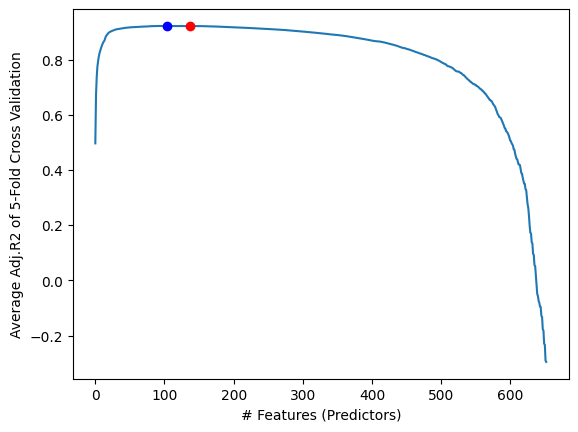

In [33]:
# ### Plot Adjusted R² Changes During Forward Selection ### #
# adjr2_list: list[float] = [i.avg_adjr2 for i in forward_best_list]
adjr2_max = max(adjr2_list)
adjr2_max_index = np.argmax(adjr2_list)
print(f"adj.R2-max: {adjr2_max} (columns: {adjr2_max_index + 1})")

plt.plot(adjr2_list)
plt.xlabel("# Features (Predictors)")
plt.ylabel("Average Adj.R2 of 5-Fold Cross Validation")
plt.plot(104, adjr2_list[104], "ob");
plt.plot(adjr2_max_index, adjr2_max, "or");

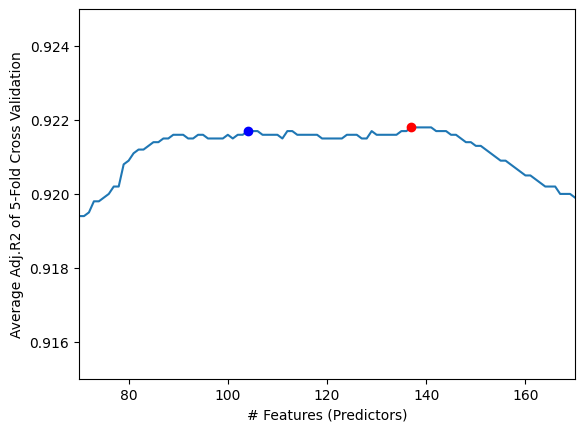

In [34]:
# ### Plot Adjusted R² Changes During Forward Selection (Partially) ### #
plt.xlim(70, 170)
plt.ylim(0.915, 0.925)
plt.plot(adjr2_list)
plt.xlabel("# Features (Predictors)")
plt.ylabel("Average Adj.R2 of 5-Fold Cross Validation")
plt.plot(104, adjr2_list[104], "ob");
plt.plot(adjr2_max_index, adjr2_max, "or");

# Demonstration of Overfitting vs Underfitting

Using the forward selection method described in the previous section, both overfitting and underfitting behaviors are observed (the graph below). For models with fewer than around 50 parameters, the cross-validation RMSE values are relatively high, indicating underfitting. As the number of parameters increases, the RMSE decreases and reaches its minimum value of **18,029** at around **178 parameters**. Beyond this point, the RMSE remains low but gradually begins to rise again, suggesting that models with an excessive number of parameters, such as those exceeding 400, are overfitting to the training data.

In [35]:
rmse_list: list[float] = [50571, 40764, 36471, 33642, 31989, 30722, 29736, 28946, 28237, 27541, 26873, 26353, 25917, 25565, 24971, 24060, 23645, 23267, 22940, 22586, 22362, 22152, 22002, 21850, 21716, 21607, 21480, 21337, 21198, 21103, 21008, 20933, 20859, 20792, 20719, 20664, 20607, 20548, 20482, 20385, 20311, 20256, 20198, 20151, 20108, 20064, 20011, 19974, 19928, 19892, 19855, 19813, 19780, 19750, 19723, 19692, 19656, 19623, 19593, 19565, 19533, 19503, 19470, 19443, 19417, 19388, 19353, 19326, 19305, 19283, 19262, 19238, 19213, 19191, 19166, 19145, 19125, 19104, 19080, 18988, 18959, 18933, 18910, 18890, 18870, 18853, 18837, 18810, 18794, 18780, 18767, 18755, 18743, 18729, 18714, 18702, 18690, 18675, 18662, 18650, 18636, 18625, 18611, 18594, 18581, 18571, 18561, 18551, 18538, 18529, 18521, 18514, 18483, 18473, 18464, 18451, 18438, 18428, 18422, 18417, 18410, 18399, 18389, 18376, 18360, 18348, 18341, 18333, 18325, 18297, 18290, 18281, 18274, 18260, 18249, 18234, 18220, 18206, 18191, 18177, 18169, 18160, 18153, 18145, 18139, 18133, 18129, 18123, 18119, 18114, 18109, 18105, 18101, 18097, 18093, 18089, 18086, 18082, 18079, 18076, 18074, 18073, 18071, 18070, 18067, 18064, 18052, 18050, 18045, 18042, 18039, 18037, 18035, 18033, 18031, 18030, 18030, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18029, 18030, 18030, 18031, 18031, 18031, 18032, 18033, 18033, 18032, 18033, 18033, 18033, 18034, 18036, 18037, 18038, 18039, 18040, 18041, 18042, 18044, 18045, 18045, 18048, 18050, 18050, 18051, 18053, 18056, 18059, 18061, 18063, 18066, 18069, 18072, 18076, 18080, 18083, 18076, 18080, 18076, 18074, 18077, 18081, 18085, 18086, 18088, 18091, 18093, 18091, 18095, 18100, 18104, 18108, 18113, 18119, 18119, 18124, 18130, 18136, 18124, 18124, 18124, 18129, 18131, 18135, 18139, 18143, 18141, 18143, 18147, 18151, 18155, 18161, 18166, 18172, 18178, 18184, 18190, 18194, 18201, 18208, 18212, 18219, 18226, 18235, 18243, 18247, 18257, 18266, 18274, 18283, 18293, 18304, 18315, 18326, 18329, 18340, 18351, 18362, 18372, 18380, 18384, 18390, 18398, 18408, 18419, 18416, 18426, 18432, 18441, 18453, 18466, 18474, 18485, 18496, 18498, 18510, 18520, 18531, 18539, 18545, 18545, 18553, 18552, 18562, 18572, 18584, 18586, 18597, 18607, 18620, 18626, 18641, 18644, 18656, 18671, 18685, 18691, 18700, 18697, 18697, 18697, 18708, 18722, 18732, 18746, 18761, 18769, 18769, 18781, 18795, 18812, 18812, 18831, 18849, 18868, 18887, 18906, 18925, 18943, 18962, 18977, 18996, 19016, 19035, 19035, 19056, 19076, 19095, 19117, 19118, 19139, 19161, 19161, 19183, 19201, 19221, 19244, 19267, 19288, 19310, 19333, 19354, 19376, 19397, 19422, 19422, 19440, 19463, 19485, 19508, 19527, 19539, 19561, 19585, 19585, 19611, 19611, 19611, 19611, 19611, 19611, 19611, 19611, 19611, 19631, 19638, 19656, 19683, 19713, 19739, 19739, 19769, 19799, 19831, 19861, 19877, 19900, 19929, 19962, 19995, 20028, 20028, 20057, 20087, 20120, 20148, 20181, 20215, 20252, 20290, 20328, 20372, 20414, 20457, 20487, 20533, 20533, 20543, 20551, 20579, 20625, 20673, 20673, 20719, 20719, 20763, 20803, 20844, 20867, 20890, 20933, 20983, 21013, 21065, 21116, 21153, 21153, 21197, 21240, 21268, 21308, 21349, 21349, 21386, 21425, 21473, 21517, 21518, 21560, 21608, 21608, 21656, 21702, 21753, 21753, 21807, 21856, 21912, 21967, 21974, 21974, 21991, 22030, 22084, 22084, 22138, 22201, 22201, 22273, 22320, 22385, 22450, 22509, 22571, 22642, 22656, 22724, 22724, 22804, 22900, 22977, 23027, 22996, 23031, 23074, 23079, 23122, 23157, 23233, 23306, 23379, 23462, 23542, 23610, 23591, 23585, 23585, 23587, 23659, 23725, 23726, 23808, 23893, 24000, 24000, 24096, 24186, 24276, 24348, 24431, 24508, 24580, 24649, 24745, 24745, 24830, 24912, 24983, 24983, 25010, 25058, 25059, 25147, 25161, 25180, 25233, 25313, 25394, 25402, 25494, 25528, 25651, 25661, 25760, 25856, 25856, 25961, 26081, 26189, 26305, 26430, 26557, 26556, 26677, 26677, 26829, 27001, 27114, 27203, 27313, 27516, 27745, 27964, 28159, 28273, 28471, 28471, 28478, 28640, 28823, 28988, 29131, 29323, 29538, 29540, 29806, 29810, 29896, 30011, 30244, 30496, 30725, 30764, 30964, 31042, 31157, 31456, 31457, 31773, 31972, 32190, 32190, 32482, 32741, 32695, 32690, 33035, 33409, 33409, 33792, 34077, 34316, 34295, 34698, 34727, 35344, 35959, 36213, 36716, 37508, 37961, 37962, 38625, 38689, 39452, 39475, 40368, 40369, 41159, 41671, 42266, 42371, 42740, 42779, 42960, 42890, 43473, 43473, 44260, 44284, 45150, 45150, 46136, 46149]


RMSE-min: 18029 (columns: 178)


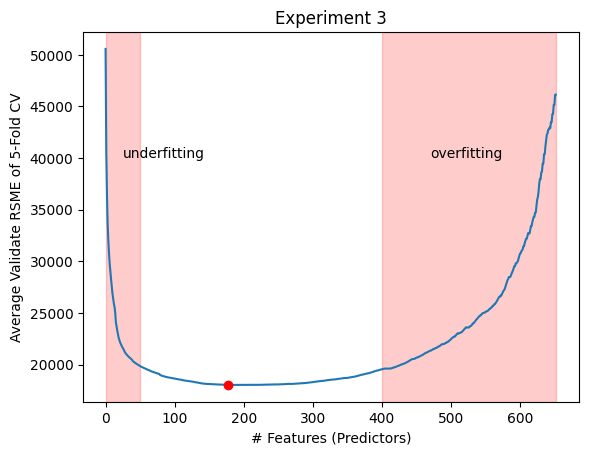

In [36]:
# ### Plot RMSE Changes During Forward Selection ### #
# rmse_list: list[float] = [i.avg_nrmse * (-1) for i in forward_best_list]
rmse_min: float = min(rmse_list)
rmse_min_index: int = np.argmin(rmse_list)
print(f"RMSE-min: {rmse_min} (columns: {rmse_min_index + 1})")

plt.plot(rmse_list)
plt.title("Experiment 3")
plt.xlabel("# Features (Predictors)")
plt.ylabel("Average Validate RSME of 5-Fold CV")
plt.axvspan(0, 50, color="red", alpha=0.2, label="underfitting")
plt.text(25, 40000, "underfitting", fontsize=10, color="black")
plt.axvspan(400, 653, color="red", alpha=0.2, label="overfitting")
plt.text(470, 40000, "overfitting", fontsize=10, color="black")
plt.plot(rmse_min_index, rmse_min, "or");

# Final Model

As I discussed in the model tuning section, I use the 105 features identified during the forward selection process for the final model. I recompute the coefficients and intercept using the entire training dataset. This model achieves the test score **RMSE = 20791**.

In [37]:
# ### Predict the test prices ### #
features_best: list[str] = ['GrLivArea', 'TotalBsmtSF', 'ExterQual_TA', 'BsmtQual_Ex', 'GarageArea', 'BsmtFinSF1', 'KitchenAbvGr_1', 'KitchenQual_Ex', 'SaleCondition_Partial', 'LotArea', 'Functional_Typ', 'Foundation_PConc', 'BsmtExposure_Gd', 'OverallQual_9', 'OverallQual_8', 'OverallQual_10', 'OverallQual_7', 'Neighborhood_Crawfor', 'SaleCondition_Normal', 'CentralAir_Y', 'Condition1_Norm', 'MSZoning_RM', 'OverallCond_7', 'LotConfig_CulDSac', 'Exterior1st_BrkFace', 'OverallCond_8', 'BsmtQual_NA', 'MSSubClass_60', 'OverallCond_9', 'OverallQual_6', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'GarageYrBlt_1963', 'BsmtFinType2_GLQ', 'RoofMatl_WdShngl', 'Heating_GasW', 'BsmtCond_Fa', 'Exterior2nd_VinylSd', 'Neighborhood_StoneBr', 'Neighborhood_Somerst', 'Fireplaces_2', 'MSSubClass_20', 'MSSubClass_80', 'YearBuilt_1989', 'Neighborhood_BrkSide', 'LotShape_IR2', 'LandContour_Low', 'Neighborhood_ClearCr', 'GarageYrBlt_1953', 'OverallQual_5', 'HalfBath_1', 'FullBath_1', 'YearBuilt_1973', 'BsmtExposure_No', 'LotConfig_FR2', 'GarageCars_3', 'GarageYrBlt_2007', 'LotShape_IR1', '1stFlrSF', 'GarageType_BuiltIn', 'OverallCond_6', 'GarageCars_4', 'GarageCars_2', 'PoolArea', 'Exterior2nd_Plywood', 'YearBuilt_1892', 'WoodDeckSF', 'YearRemodAdd_1962', 'GarageQual_Fa', 'YearBuilt_1936', 'YearBuilt_1984', 'YrSold_2007', 'BsmtFullBath_0', 'YearRemodAdd_2008', 'Condition2_PosN', 'GarageYrBlt_1923', 'MoSold_7', 'GarageYrBlt_1932', 'FullBath_3', 'BedroomAbvGr_5', 'SaleType_CWD', 'YearBuilt_1872', 'BsmtFinType2_BLQ', 'Neighborhood_NPkVill', 'LotFrontage', 'HouseStyle_2.5Unf', 'GarageYrBlt_1992', 'Neighborhood_SawyerW', 'OverallCond_5', 'YearRemodAdd_1965', 'GarageYrBlt_1971', 'GarageYrBlt_1929', 'YearRemodAdd_1958', 'BsmtFinType1_LwQ', 'GarageType_Detchd', 'Condition1_RRAe', 'GarageType_Attchd', 'ScreenPorch', 'GarageYrBlt_1915', 'YearBuilt_1925', 'Exterior1st_Stucco', 'GarageYrBlt_1986', 'YearRemodAdd_1991', 'YearBuilt_1958', 'MoSold_5']
predictions_list: list[int] = predict_test_prices(
    features_best=features_best,
    X_train_df=X_train_df_3,
    y_train_df=y_train_df_3,
    X_test_df=X_test_df_3
)

intercept: -23207.364885804796
coefficients: [ 4.10128168e+01  1.26387182e+01 -6.72483432e+03  9.32365863e+03
  3.44617652e+00  1.83881871e+01  1.40147927e+04  1.50180883e+04
  3.00647018e+04  5.71344886e-01  1.58577653e+04  6.70692294e+03
  1.53693160e+04  6.37782345e+04  3.69796579e+04  8.46446251e+04
  1.85219731e+04  2.57305709e+04  8.07677290e+03  4.77903779e+03
  6.76634046e+03 -2.58658029e+03  1.91910469e+04  1.42524217e+04
  1.65799128e+04  1.84641136e+04  4.94686581e+03  1.19110425e+04
  1.71175810e+04  8.45974019e+03  2.71376119e+04  1.95908357e+04
 -2.25544272e+04  1.58651445e+04  3.30817881e+04 -1.07419484e+04
 -4.67968312e+03  5.28479828e+03  3.17159793e+04  1.26637057e+04
  6.40295244e+03  8.72569050e+03  8.99096586e+03  2.14615511e+04
  9.79425962e+03  1.07159049e+04 -1.16779405e+04  2.29362189e+04
 -1.58194005e+04  4.59957431e+03  6.22693807e+03 -5.78628487e+03
 -1.25379739e+04 -3.73417535e+03 -8.48648880e+03  1.55361224e+04
 -9.87595061e+03 -3.56206623e+03  1.19431683e